# **mobility_package — Pittsburgh (Docked) Example Run**

This notebook runs the complete fairness analysis pipeline for Pittsburgh's
Healthy Ride docked bike-share system using one day of GBFS data.

**Pipeline overview:**
1. Load Context → parse station status, geocode stations to census blocks
2. Compute Metrics → availability, capacity, safety, usage, idle time
3. Fairness Calculation → Gini + Alpha fairness per metric
4. Choropleth Maps → one map per metric
5. Capacity Decile Map → station capacity by tract
6. Correlation Maps → pairwise metric comparisons
7. Scatter Plot → supply vs demand classification
8. Fairness Trend → time-series fairness (requires 7 days)
9. Summary Table → paper-style fairness table

## Cell 0 — Imports
Run this first. If any import fails, check that `mobility_package` is
in the same directory as this notebook or is installed in your environment.

In [2]:
# ============================================================
# Cell 0 — Imports
# ============================================================
from pathlib import Path
from mobility_package import (
    docked_wrapper,
    fairness_calculation,
    map_visual,
    capacity_map_visual,
    correlation_visual,
    scatter_visual,
    trend_visual,
    table_visual,
)
print("All modules loaded.")

All modules loaded.


## Cell 1 — File Paths

**This is the only cell you need to edit.**
Update the filenames to match what is inside your `PITT_ASSETS` folder.
Every other cell reads from these variables — nothing else needs to change.

Expected folder structure:

PITT_ASSETS/

pitt_docked_station_status_6_9.txt

pitt_station_information_06_09.csv

pitt_tripdata_june_2025.csv

tl_2024_42_tract.shp   (+ .dbf .prj .shx)


All outputs will be saved inside `PITT_ASSETS/PITT_OUTPUT/`.

#### Use the following link to download the PITT Data: https://data.wprdc.org/dataset/pogoh-trip-data

In [3]:
# # ============================================================
# # Cell 1 — Paths (edit ONLY this cell)
# # ============================================================

# PITT_ASSETS   = Path("PITT_ASSETS")

# PITT_STATUS   = PITT_ASSETS / "pitt_gbfs_docked_station_status_6_9.txt"
# PITT_INFO     = PITT_ASSETS / "pitt_station_information_06_09.csv"
# PITT_TRIPS    = PITT_ASSETS / "pitt_tripdata_june_2025.csv"
# PITT_TRACT    = PITT_ASSETS / "tl_2024_42_tract.shp"
# PITT_OUT      = PITT_ASSETS / "PITT_OUTPUT"
# PITT_FAIR_DIR = PITT_OUT / "FAIRNESS_RESULTS"

# PITT_START = "2025-06-09 00:00:00"  
# PITT_END   = "2025-06-09 23:59:59"

# print("Paths configured.")

In [4]:
# ============================================================
# Cell 1 — Paths (edit only this cell)
# ============================================================

from pathlib import Path

# ── User-provided data files ──────────────────────────────────
# These are the only files you need to supply.
# All spatial assets (shapefiles, centerlines, bike lanes) are
# already configured inside the package under assets/PITT/

PITT_STATUS   = Path("PITT_ASSETS/pitt_gbfs_docked_station_status_6_9.txt")
PITT_INFO     = Path("PITT_ASSETS/pitt_station_information_06_09.csv")
PITT_TRIPS    = Path("PITT_ASSETS/pitt_tripdata_june_2025.csv")

# ── Output directories ────────────────────────────────────────
PITT_OUT      = "PITT_OUTPUT"
PITT_FAIR_DIR = "PITT_OUTPUT/FAIRNESS_RESULTS"

# ── Tract shapefile (used by visualization modules only) ──────
# This is already in the assets folder from the package setup
PITT_TRACT    = Path("assets/PITT/tl_2024_42_tract.shp")

# ── Date window — must match the date of your data files ──────
PITT_START = "2025-06-09 00:00:00"
PITT_END   = "2025-06-09 23:59:59"

print("Paths configured.")
print(f"  Status file : {PITT_STATUS}")
print(f"  Info file   : {PITT_INFO}")
print(f"  Trip file   : {PITT_TRIPS}")
print(f"  Output dir  : {PITT_OUT}")

Paths configured.
  Status file : PITT_ASSETS\pitt_gbfs_docked_station_status_6_9.txt
  Info file   : PITT_ASSETS\pitt_station_information_06_09.csv
  Trip file   : PITT_ASSETS\pitt_tripdata_june_2025.csv
  Output dir  : PITT_OUTPUT


## Cell 2 — Load Context

Parses the raw station status file, geocodes every station to a census
block using the Pittsburgh census blocks shapefile, and builds the shared
`ctx` dictionary that every downstream compute function reads from.

This cell must always run before any Cell 3 metric functions.

In [5]:
# ============================================================
# Cell 2 — Load Context
# ============================================================
# Parses the station status file, geocodes all stations to census
# blocks using the Pittsburgh shapefile, and builds the shared ctx
# dictionary that every downstream compute function reads from.

pitt_ctx = docked_wrapper.load_docked_context(
    city                    = "PITT",
    station_status_txt      = PITT_STATUS,
    station_information_csv = PITT_INFO,
    output_dir              = PITT_OUT,
    remove_tz_suffix        = " EDT",
)

[PITT] Loading spatial assets...
[PITT] Loading station status...
[PITT] Geocoding stations to census blocks...


## Cell 3 — Compute Metrics

Computes all five utility metrics and saves one CSV per metric to
`PITT_OUTPUT/`.

**Option A** runs everything in one call.
**Option B** lets you run individual metrics — useful if you only need
one or two, or if one metric fails and you want to re-run it alone.

Files saved to `PITT_OUTPUT/`:

| File | Metric |
|---|---|
| `availability__norm__tract.csv` | Availability |
| `capacity_tract_norm.csv` | Capacity (basic) |
| `capacity_tract_with_vehicle_and_docks_norm.csv` | Capacity (full) |
| `safety_bike_lane_norm_tract.csv` | Safety |
| `usage_norm_hourly_tract.csv` | Usage |
| `idle_time_norm_tract.csv` | Idle Time |

In [6]:
# ============================================================
# Cell 3 — Compute Metrics
# ============================================================

# ── OPTION A — All metrics at once ───────────────────────────
pitt_results = docked_wrapper.compute_all(
    pitt_ctx,
    trip_csv   = PITT_TRIPS,
    time_start = PITT_START,
    time_end   = PITT_END,
)

# ── OPTION B — Individual metrics ────────────────────────────
# Uncomment only the metrics you need and comment out compute_all above.

# Availability — vehicles, e-bikes, docks available per tract per hour
# avail = docked_wrapper.compute_availability(
#     pitt_ctx,
#     time_start = PITT_START,
#     time_end   = PITT_END,
# )

# Capacity — station dock count and vehicle occupancy per tract
# cap = docked_wrapper.compute_capacity(
#     pitt_ctx,
#     time_start = PITT_START,
#     time_end   = PITT_END,
# )

# Safety — bike lane and protected lane ratio per tract
# safe = docked_wrapper.compute_safety(
#     pitt_ctx,
#     time_start = PITT_START,
#     time_end   = PITT_END,
# )

# Usage — trip starts and ends per tract per hour (needs trip CSV)
# usage = docked_wrapper.compute_usage(
#     pitt_ctx,
#     trip_csv   = PITT_TRIPS,
#     time_start = PITT_START,
#     time_end   = PITT_END,
# )

# Idle Time — average time a bike sits unused per tract (needs trip CSV)
# idle = docked_wrapper.compute_idle_time(
#     pitt_ctx,
#     trip_csv   = PITT_TRIPS,
#     time_start = PITT_START,
#     time_end   = PITT_END,
# )

[PITT] Computing availability...
[PITT] Computing capacity...
[PITT] Computing safety...
[PITT] Computing usage...
   -> Reading trip data from: PITT_ASSETS\pitt_tripdata_june_2025.csv
[PITT] Computing idle time...
   -> Reading trip data from: PITT_ASSETS\pitt_tripdata_june_2025.csv
--- Done. Outputs saved to PITT_OUTPUT ---


## Cell 4 — Fairness Calculation

Reads the CSVs saved by Cell 3 and computes two fairness metrics for
every utility:

- **Gini Coefficient** — 0 = perfectly equal, 1 = perfectly unequal
- **Alpha Fairness (α = 1)** — sum of log(x+1) across all tracts,
  higher = more total utility delivered fairly

`filter_to_capacity_service_area = True` restricts the fairness
calculation to only tracts that have at least one station, matching
the paper's methodology.

Results are saved to `PITT_OUTPUT/FAIRNESS_RESULTS/`.

In [7]:
# ============================================================
# Cell 4 — Fairness Calculation
# ============================================================
# Reads the CSVs saved by compute_all and computes Gini coefficient
# and Alpha fairness (α=1) for every metric.
# Note: capacity uses the _with_vehicle_and_docks_norm file, not
# capacity_tract_norm.csv — this is the fuller version with all columns.

pitt_fairness = fairness_calculation.run_paper_style_fairness(
    city_key       = "PITT_DOCKED",
    save_directory = PITT_FAIR_DIR,

    capacity_csv     = f"{PITT_OUT}/capacity_tract_with_vehicle_and_docks_norm.csv",
    availability_csv = f"{PITT_OUT}/availability__norm__tract.csv",
    safety_csv       = f"{PITT_OUT}/safety_bike_lane_norm_tract.csv",
    usage_csv        = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
    idle_time_csv    = f"{PITT_OUT}/idle_time_norm_tract.csv",

    filter_to_capacity_service_area = True,
)

display(pitt_fairness["fairness_table"])
print("Saved to:", pitt_fairness["saved_to"])

  [fairness] Capacity: Total capacity → 'total_capacity', Vehicle capacity → 'vehicle_capacity', Number of stations → 'num_station', Dock capacity → 'dock_capacity'
  [fairness] Safety: Bike lane ratio → 'bike_lane_ratio', Protected bike lane ratio → 'protected_bike_lane_length'
  [fairness] Availability: Total vehicles available → 'total_vehicle_available', Bikes available → 'num_bikes_available', E-bikes available → 'num_ebikes_available', Docks available → 'num_docks_available'
  [fairness] Idle Time: Average idle time → 'avg_idle_time'
  [fairness] Usage: Trips starting → 'trips_starting', Trips ending → 'trips_ending'


,Utility,Metric,Min,Max,Mean,StDev,Gini Coefficient,"Alpha Fairness (α = 1, Normalized)"
0,Capacity,Total capacity,15.000000,102.000000,29.722222,20.382922,0.306803,8.857498
1,Capacity,Vehicle capacity,2.000000,75.000000,19.527778,15.757966,0.404893,7.904261
2,Capacity,Number of stations,1.000000,6.000000,1.666667,1.121224,0.284253,8.511911
3,Capacity,Dock capacity,2.000000,62.000000,16.277778,11.775546,0.340350,8.054304
4,Safety,Bike lane ratio,0.000000,0.150703,0.022668,0.037386,0.727361,1.346626
5,Safety,Protected bike lane ratio,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Availability,Total vehicles available,3.875000,81.708333,18.937500,15.299926,0.369016,5.507004
7,Availability,Bikes available,3.250000,53.625000,12.443287,10.143050,0.371988,5.812372
8,Availability,E-bikes available,0.416667,28.041667,6.468750,5.459223,0.399367,4.962023
9,Availability,Docks available,6.041667,63.500000,16.620370,11.576603,0.339837,5.810663


Saved to: PITT_OUTPUT\FAIRNESS_RESULTS\PITT_DOCKED_fairness_results.csv


## Cell 5 — Choropleth Maps

Produces one choropleth PNG per metric showing how each utility is
distributed across Pittsburgh census tracts. Only tracts with at least
one station are shown.

**Option A** produces all four maps in one call.
**Option B** produces one map at a time — useful if you only need a
specific metric or want to re-run one map with different settings.

Files saved to `PITT_OUTPUT/MAPS/`:

| File | Metric |
|---|---|
| `availability_rank__mean.png` | Availability |
| `usage_rank__mean.png` | Usage |
| `idle_time_rank__mean.png` | Idle Time |
| `safety_rank__mean.png` | Safety |

In [8]:
# ============================================================
# Cell 5 — Choropleth Maps
# ============================================================

# ── OPTION A — All four maps at once ─────────────────────────
map_visual.plot_all(
    availability_csv = f"{PITT_OUT}/availability__norm__tract.csv",
    usage_csv        = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
    idle_time_csv    = f"{PITT_OUT}/idle_time_norm_tract.csv",
    safety_csv       = f"{PITT_OUT}/safety_bike_lane_norm_tract.csv",
    capacity_csv     = f"{PITT_OUT}/capacity_tract_norm.csv",
    tract_shp        = PITT_TRACT,
    output_dir       = f"{PITT_OUT}/MAPS",
)

# ── OPTION B — One map at a time ─────────────────────────────
# Uncomment whichever map you want and comment out plot_all above.

# Availability map → availability_rank__mean.png
# map_visual.plot_map(
#     metric       = "availability",
#     csv          = f"{PITT_OUT}/availability__norm__tract.csv",
#     capacity_csv = f"{PITT_OUT}/capacity_tract_norm.csv",
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/MAPS",
# )

# Usage map → usage_rank__mean.png
# map_visual.plot_map(
#     metric       = "usage",
#     csv          = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
#     capacity_csv = f"{PITT_OUT}/capacity_tract_norm.csv",
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/MAPS",
# )

# Idle time map → idle_time_rank__mean.png
# map_visual.plot_map(
#     metric       = "idle_time",
#     csv          = f"{PITT_OUT}/idle_time_norm_tract.csv",
#     capacity_csv = f"{PITT_OUT}/capacity_tract_norm.csv",
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/MAPS",
# )

# Safety map → safety_rank__mean.png
# map_visual.plot_map(
#     metric       = "safety",
#     csv          = f"{PITT_OUT}/safety_bike_lane_norm_tract.csv",
#     capacity_csv = f"{PITT_OUT}/capacity_tract_norm.csv",
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/MAPS",
# )

Plotting availability map...
   -> Saved: PITT_OUTPUT\MAPS\availability_rank__mean.png
Plotting usage map...
   -> Saved: PITT_OUTPUT\MAPS\usage_rank__mean.png
Plotting idle_time map...
   -> Saved: PITT_OUTPUT\MAPS\idle_time_rank__mean.png
Plotting safety map...
   -> Saved: PITT_OUTPUT\MAPS\safety_rank__mean.png


{'availability': WindowsPath('PITT_OUTPUT/MAPS/availability_rank__mean.png'),
 'usage': WindowsPath('PITT_OUTPUT/MAPS/usage_rank__mean.png'),
 'idle_time': WindowsPath('PITT_OUTPUT/MAPS/idle_time_rank__mean.png'),
 'safety': WindowsPath('PITT_OUTPUT/MAPS/safety_rank__mean.png')}

## Cell 6 — Capacity Decile Map

Plots station capacity across Pittsburgh census tracts using decile bins
(1–10%, 11–20%, ... 91–100%). Only tracts with at least one station are
shown. Each capacity column in the CSV produces one PNG.

Files saved to `PITT_OUTPUT/CAPACITY_MAPS/`.

In [9]:
# ============================================================
# Cell 6 — Capacity Decile Map
# ============================================================
# Uses the fuller capacity file with vehicle and dock columns.
# Only tracts with at least 1 station are included.

capacity_map_visual.plot_capacity(
    capacity_csv      = f"{PITT_OUT}/capacity_tract_with_vehicle_and_docks_norm.csv",
    tract_shp         = PITT_TRACT,
    output_dir        = f"{PITT_OUT}/CAPACITY_MAPS",
    capacity_norm_col = "total_capacity_norm",
    station_count_col = "num_station",
    min_stations      = 1,
    drop_zeros        = True,
)

  [capacity_map] Station count column : 'num_station'
  [capacity_map] Gate column          : 'total_capacity_norm'
  [capacity_map] Columns to plot: ['total_capacity_norm', 'num_station_norm', 'vehicle_capacity_norm', 'dock_capacity_norm', 'occupancy_rate', 'return_pressure']
   -> Saved: PITT_OUTPUT\CAPACITY_MAPS\total_capacity_norm_gate__total_capacity_norm.png
   -> Saved: PITT_OUTPUT\CAPACITY_MAPS\total_capacity_norm_gate__num_station_norm.png
   -> Saved: PITT_OUTPUT\CAPACITY_MAPS\total_capacity_norm_gate__vehicle_capacity_norm.png
   -> Saved: PITT_OUTPUT\CAPACITY_MAPS\total_capacity_norm_gate__dock_capacity_norm.png
   -> Saved: PITT_OUTPUT\CAPACITY_MAPS\total_capacity_norm_gate__occupancy_rate.png
   -> Saved: PITT_OUTPUT\CAPACITY_MAPS\total_capacity_norm_gate__return_pressure.png


{'total_capacity_norm': WindowsPath('PITT_OUTPUT/CAPACITY_MAPS/total_capacity_norm_gate__total_capacity_norm.png'),
 'num_station_norm': WindowsPath('PITT_OUTPUT/CAPACITY_MAPS/total_capacity_norm_gate__num_station_norm.png'),
 'vehicle_capacity_norm': WindowsPath('PITT_OUTPUT/CAPACITY_MAPS/total_capacity_norm_gate__vehicle_capacity_norm.png'),
 'dock_capacity_norm': WindowsPath('PITT_OUTPUT/CAPACITY_MAPS/total_capacity_norm_gate__dock_capacity_norm.png'),
 'occupancy_rate': WindowsPath('PITT_OUTPUT/CAPACITY_MAPS/total_capacity_norm_gate__occupancy_rate.png'),
 'return_pressure': WindowsPath('PITT_OUTPUT/CAPACITY_MAPS/total_capacity_norm_gate__return_pressure.png')}

## Cell 7 — Correlation Maps

Compares every pair of metrics side by side on a map. Each tract is
colored based on whether it is high or low on both metrics, producing
four quadrants:

| Color | Meaning |
|---|---|
| Dark blue | High on both metrics |
| Light blue | High X, Low Y |
| Light orange | Low X, High Y |
| Dark orange | Low on both metrics |

All six pairwise combinations are run automatically. One PNG per pair
is saved to `PITT_OUTPUT/CORRELATION_MAPS/`.

To run only a specific pair, comment out the loop and uncomment the
single call at the bottom.

In [10]:
# ============================================================
# Cell 7 — Correlation Maps
# ============================================================

PITT_CAP = f"{PITT_OUT}/capacity_tract_norm.csv"

# ── OPTION A — All six pairs at once ─────────────────────────
pairs = [
    ("availability", f"{PITT_OUT}/availability__norm__tract.csv",  "usage",     f"{PITT_OUT}/usage_norm_hourly_tract.csv"),
    ("availability", f"{PITT_OUT}/availability__norm__tract.csv",  "idle_time", f"{PITT_OUT}/idle_time_norm_tract.csv"),
    ("availability", f"{PITT_OUT}/availability__norm__tract.csv",  "safety",    f"{PITT_OUT}/safety_bike_lane_norm_tract.csv"),
    ("usage",        f"{PITT_OUT}/usage_norm_hourly_tract.csv",    "idle_time", f"{PITT_OUT}/idle_time_norm_tract.csv"),
    ("usage",        f"{PITT_OUT}/usage_norm_hourly_tract.csv",    "safety",    f"{PITT_OUT}/safety_bike_lane_norm_tract.csv"),
    ("idle_time",    f"{PITT_OUT}/idle_time_norm_tract.csv",       "safety",    f"{PITT_OUT}/safety_bike_lane_norm_tract.csv"),
]

for mx, cx, my, cy in pairs:
    correlation_visual.plot_correlation(
        metric_x     = mx,
        csv_x        = cx,
        metric_y     = my,
        csv_y        = cy,
        capacity_csv = PITT_CAP,
        tract_shp    = PITT_TRACT,
        output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
    )

# ── OPTION B — One pair at a time ────────────────────────────
# Comment out the loop above and uncomment one block below.

# Availability vs Usage → correlation_availability_vs_usage__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "availability",
#     csv_x        = f"{PITT_OUT}/availability__norm__tract.csv",
#     metric_y     = "usage",
#     csv_y        = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
#     capacity_csv = PITT_CAP,
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
# )

# Availability vs Idle Time → correlation_availability_vs_idle_time__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "availability",
#     csv_x        = f"{PITT_OUT}/availability__norm__tract.csv",
#     metric_y     = "idle_time",
#     csv_y        = f"{PITT_OUT}/idle_time_norm_tract.csv",
#     capacity_csv = PITT_CAP,
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
# )

# Availability vs Safety → correlation_availability_vs_safety__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "availability",
#     csv_x        = f"{PITT_OUT}/availability__norm__tract.csv",
#     metric_y     = "safety",
#     csv_y        = f"{PITT_OUT}/safety_bike_lane_norm_tract.csv",
#     capacity_csv = PITT_CAP,
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
# )

# Usage vs Idle Time → correlation_usage_vs_idle_time__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "usage",
#     csv_x        = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
#     metric_y     = "idle_time",
#     csv_y        = f"{PITT_OUT}/idle_time_norm_tract.csv",
#     capacity_csv = PITT_CAP,
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
# )

# Usage vs Safety → correlation_usage_vs_safety__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "usage",
#     csv_x        = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
#     metric_y     = "safety",
#     csv_y        = f"{PITT_OUT}/safety_bike_lane_norm_tract.csv",
#     capacity_csv = PITT_CAP,
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
# )

# Idle Time vs Safety → correlation_idle_time_vs_safety__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "idle_time",
#     csv_x        = f"{PITT_OUT}/idle_time_norm_tract.csv",
#     metric_y     = "safety",
#     csv_y        = f"{PITT_OUT}/safety_bike_lane_norm_tract.csv",
#     capacity_csv = PITT_CAP,
#     tract_shp    = PITT_TRACT,
#     output_dir   = f"{PITT_OUT}/CORRELATION_MAPS",
# )

Plotting Availability × Usage correlation map...
   -> Saved: PITT_OUTPUT\CORRELATION_MAPS\correlation_availability_vs_usage__mean__quantile.png
Plotting Availability × Idle Time correlation map...
   -> Saved: PITT_OUTPUT\CORRELATION_MAPS\correlation_availability_vs_idle_time__mean__quantile.png
Plotting Availability × Safety correlation map...
   -> Saved: PITT_OUTPUT\CORRELATION_MAPS\correlation_availability_vs_safety__mean__quantile.png
Plotting Usage × Idle Time correlation map...
   -> Saved: PITT_OUTPUT\CORRELATION_MAPS\correlation_usage_vs_idle_time__mean__quantile.png
Plotting Usage × Safety correlation map...
   -> Saved: PITT_OUTPUT\CORRELATION_MAPS\correlation_usage_vs_safety__mean__quantile.png
Plotting Idle Time × Safety correlation map...
   -> Saved: PITT_OUTPUT\CORRELATION_MAPS\correlation_idle_time_vs_safety__mean__quantile.png


## Cell 8 — Supply / Demand Scatter Plot

Classifies every census tract into one of four categories based on its
availability (supply) and usage (demand) relative to a percentile threshold:

| Category | Color | Meaning |
|---|---|---|
| Undersupply | Red | Low supply + high demand |
| Oversupply | Orange | High supply + low demand |
| High demand + high supply | Green | Both high — busy but well served |
| Balanced / Other | Blue | Everything else |

The threshold method controls where the high/low boundary sits:
- `"percent"` with `availability_low_pct=30` and `usage_high_pct=70` means
  the bottom 30% of tracts by availability = low supply, top 30% by usage =
  high demand. This is the recommended setting for the paper.

Files saved to `PITT_OUTPUT/SCATTER/`:
- `scatter_supply_demand.png`
- `tract_supply_demand_classification.csv`
- `classification_summary_counts.csv`

Loading CSVs and aggregating to tract level (agg_method='mean')...
  Tracts after aggregation: 36
[THRESHOLD] method=percent
  availability low =30.0%  -> 0.095264
  availability high=70.0% -> 0.180115
  usage        low =30.0%  -> 0.001600
  usage        high=70.0% -> 0.024000

Classification summary:
  Balanced (Middle band): 22 tracts
  High-demand + High-supply: 6 tracts
  Balanced / Low-low: 3 tracts
  Access-constrained (Undersupply): 2 tracts
  Low-demand (Oversupply): 2 tracts
  Insufficient data: 1 tracts

Rendering scatter plots...
   -> Saved classification CSV: PITT_OUTPUT\SCATTER\tract_supply_demand_classification.csv
   -> Saved summary CSV:        PITT_OUTPUT\SCATTER\classification_summary_counts.csv
   -> Saved scatter PNG:        PITT_OUTPUT\SCATTER\scatter_supply_demand.png


,census_tract,availability,usage,idle_time,availability_pct,usage_pct,idle_time_pct,pressure_usage_over_supply,pressure_pct,supply_demand_class,is_undersupply,is_oversupply,explain_note,usage_rank_desc,availability_rank_desc,pressure_rank_desc,plot_group
0,42003020100,0.742804,0.056,0.787447,1.000000,0.914286,0.527778,0.075390,0.428571,High-demand + High-supply,False,False,,4.0,1.0,21.0,High demand + high supply
1,42003020300,0.231818,0.048,0.741556,0.833333,0.871429,0.305556,0.207059,0.771429,High-demand + High-supply,False,False,,5.0,7.0,9.0,High demand + high supply
2,42003030500,0.144316,0.000,0.837682,0.527778,0.171429,0.833333,0.000000,0.171429,Balanced (Middle band),False,False,,25.0,18.0,25.0,Balanced / Other
3,42003040400,0.101514,0.040,0.780492,0.333333,0.828571,0.444444,0.394035,1.000000,Balanced (Middle band),False,False,,7.0,25.0,1.0,Balanced / Other
4,42003040500,0.542047,0.168,0.624968,0.972222,1.000000,0.055556,0.309936,0.942857,High-demand + High-supply,False,False,,1.0,2.0,3.0,High demand + high supply
5,42003040600,0.259848,0.064,0.596761,0.888889,0.957143,0.027778,0.246298,0.857143,High-demand + High-supply,False,False,,2.0,5.0,6.0,High demand + high supply
6,42003050100,0.048486,0.008,0.820550,0.083333,0.400000,0.694444,0.164997,0.571429,Balanced (Middle band),False,False,,20.0,34.0,16.0,Balanced / Other
7,42003050900,0.035224,0.000,0.840237,0.027778,0.171429,0.861111,0.000000,0.171429,Balanced / Low-low,False,False,,25.0,36.0,25.0,Balanced / Other
8,42003051000,0.075758,0.024,0.648060,0.194444,0.657143,0.111111,0.316799,0.971429,Access-constrained (Undersupply),True,False,High usage with low availability suggests unme...,11.0,30.0,2.0,Undersupply
9,42003060300,0.168182,0.024,0.769957,0.611111,0.657143,0.416667,0.142702,0.542857,Balanced (Middle band),False,False,,11.0,15.0,17.0,Balanced / Other


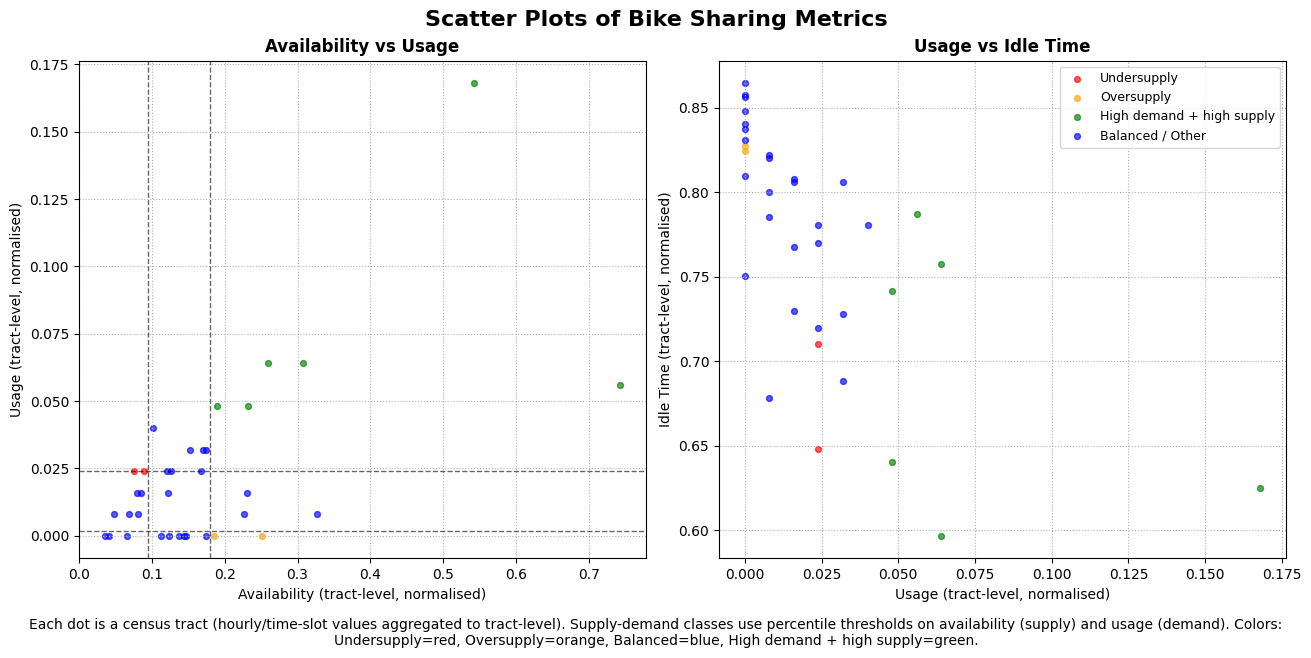

In [11]:
# ============================================================
# Cell 8 — Supply / Demand Scatter Plot
# ============================================================

master, class_df, fig = scatter_visual.plot_scatter(
    availability_csv          = f"{PITT_OUT}/availability__norm__tract.csv",
    usage_csv                 = f"{PITT_OUT}/usage_norm_hourly_tract.csv",
    idle_csv                  = f"{PITT_OUT}/idle_time_norm_tract.csv",
    output_dir                = f"{PITT_OUT}/SCATTER",
    threshold_method          = "percent",
    use_symmetric_percentiles = True,
    availability_low_pct      = 30,
    usage_high_pct            = 70,
    show_threshold_debug      = True,
)

display(class_df)

## Cell 9 — Fairness Trend

This visualization shows how Gini coefficient and Alpha fairness evolve
hour by hour over time. You can run it in two modes:

**Mode A — Single day:** Uses the CSVs already produced by Cell 3.
Plots will run and save but the trend will be a flat line — this is
expected with only one day of data. Useful for verifying the pipeline works.

**Mode B — Full week (recommended for the paper):** Collect 7 days of
daily CSVs into three folders (one per metric) and pass the folder paths.
The module auto-concatenates everything it finds inside each folder.

Set `TREND_MODE = "single"` or `TREND_MODE = "weekly"` in the cell below.

Running trend in single-day mode. Plots will be flat — this is expected.

[PITT_DOCKED] Running plot_all trend visualizations...
  [Availability] Fairness CSV saved: PITT_OUTPUT\TREND\PITT_DOCKED__availability_trend.csv


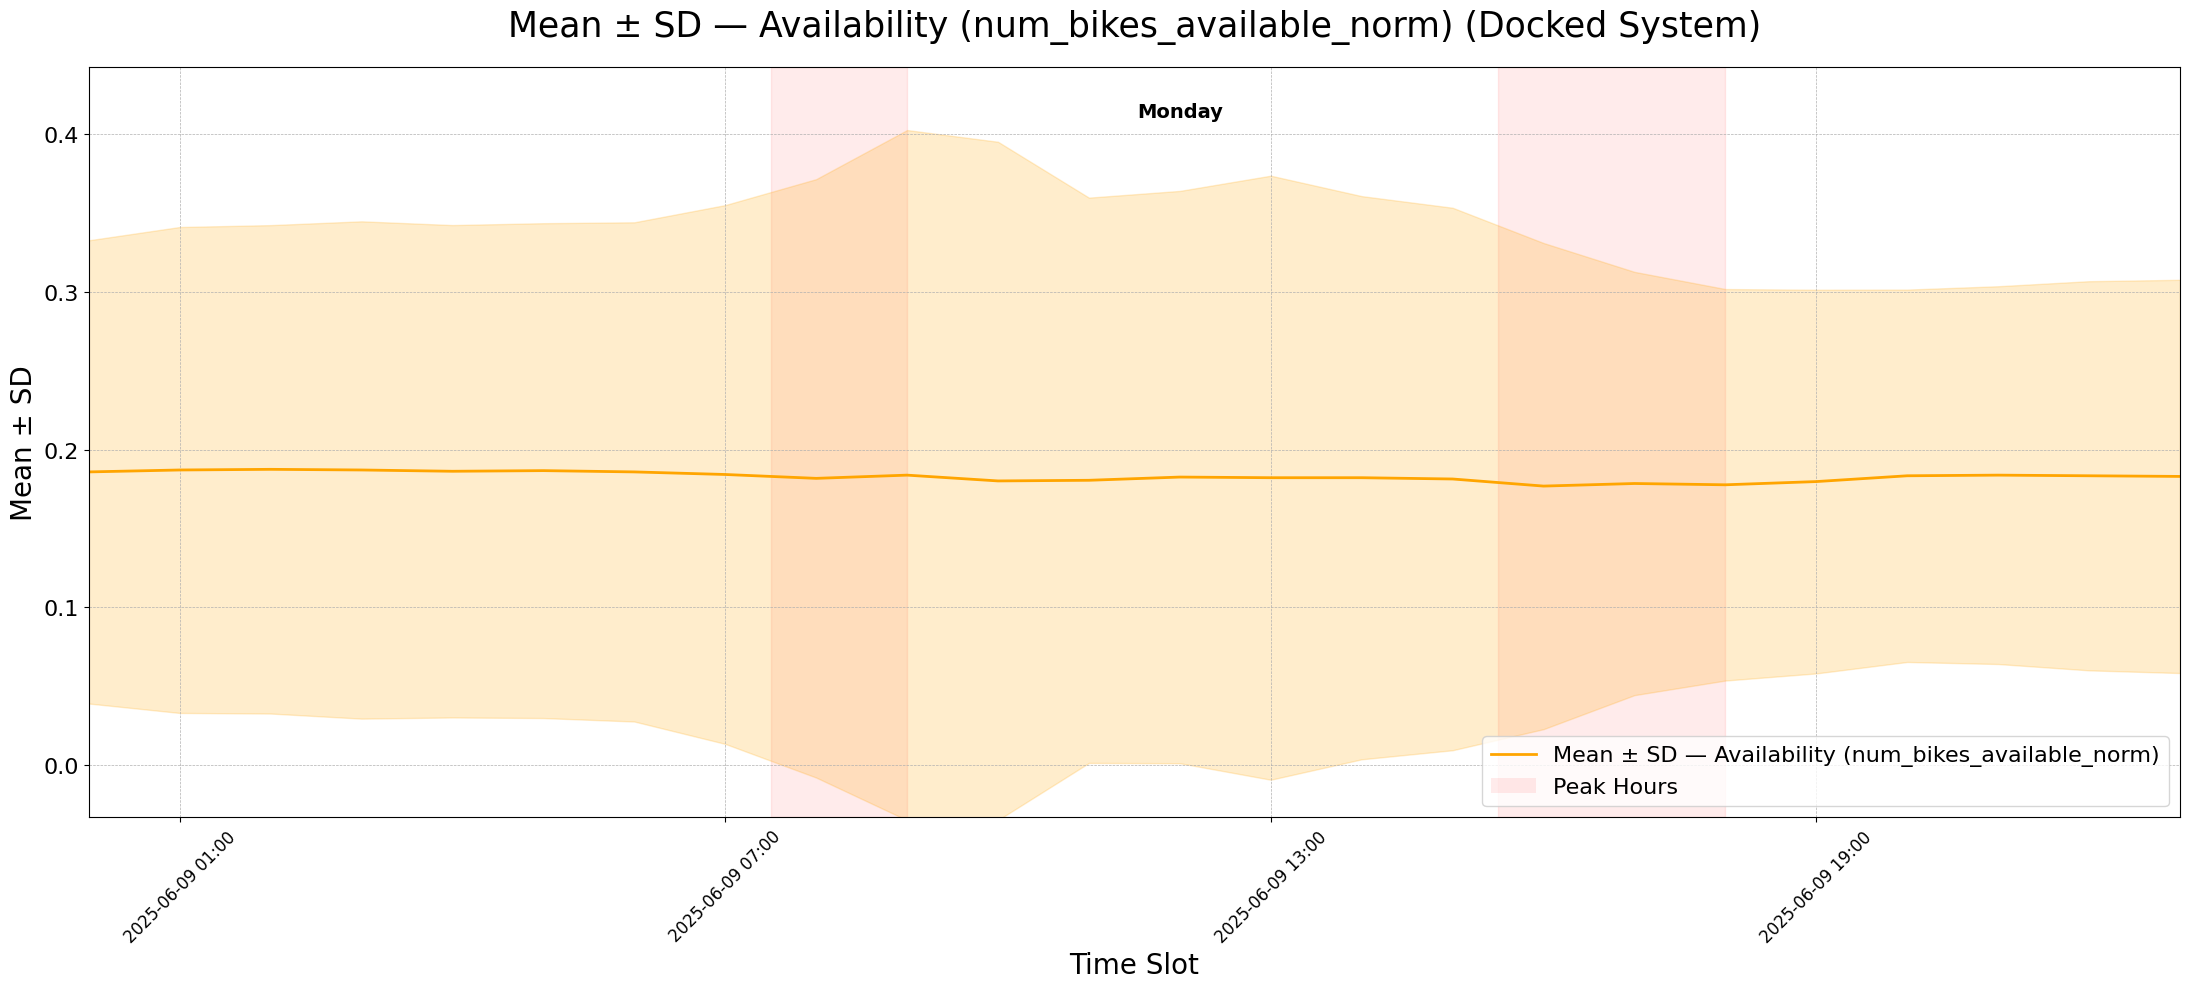

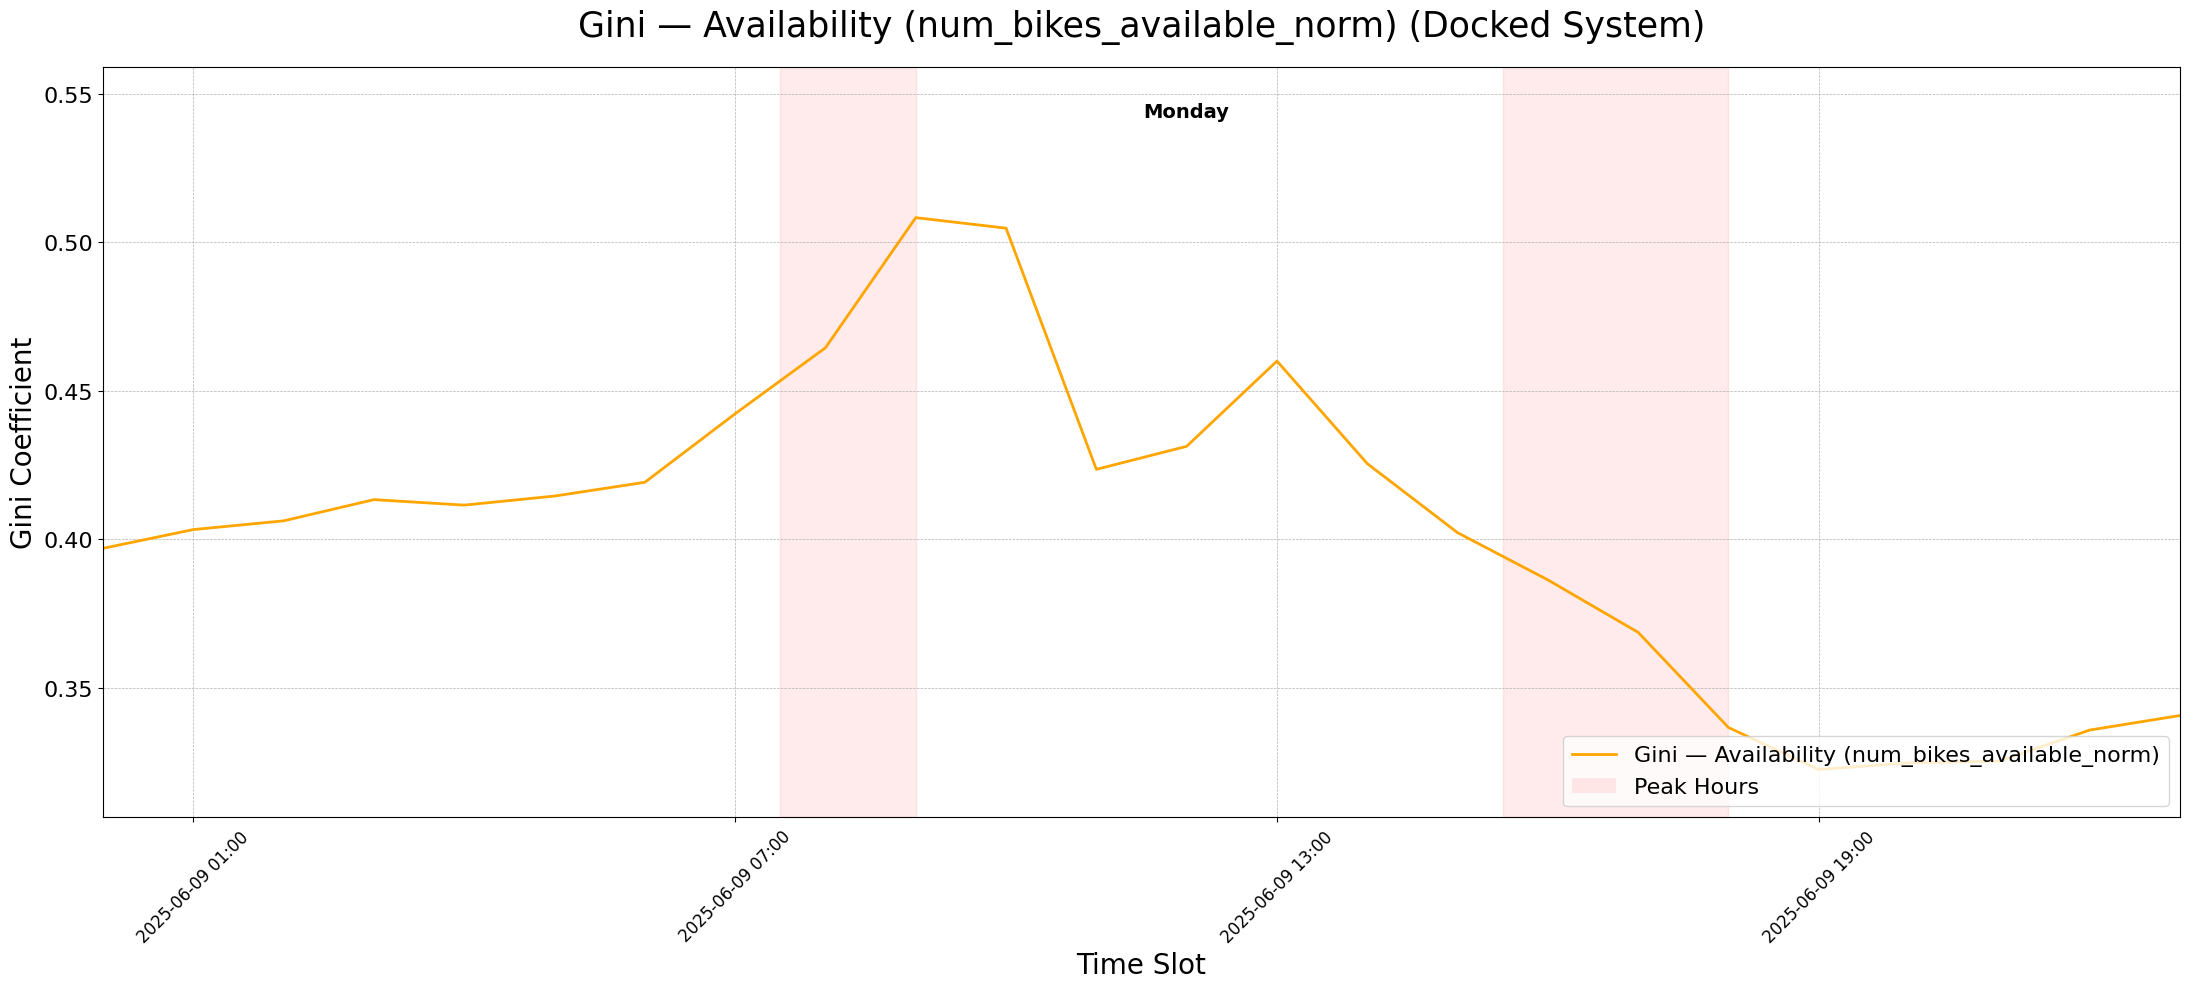

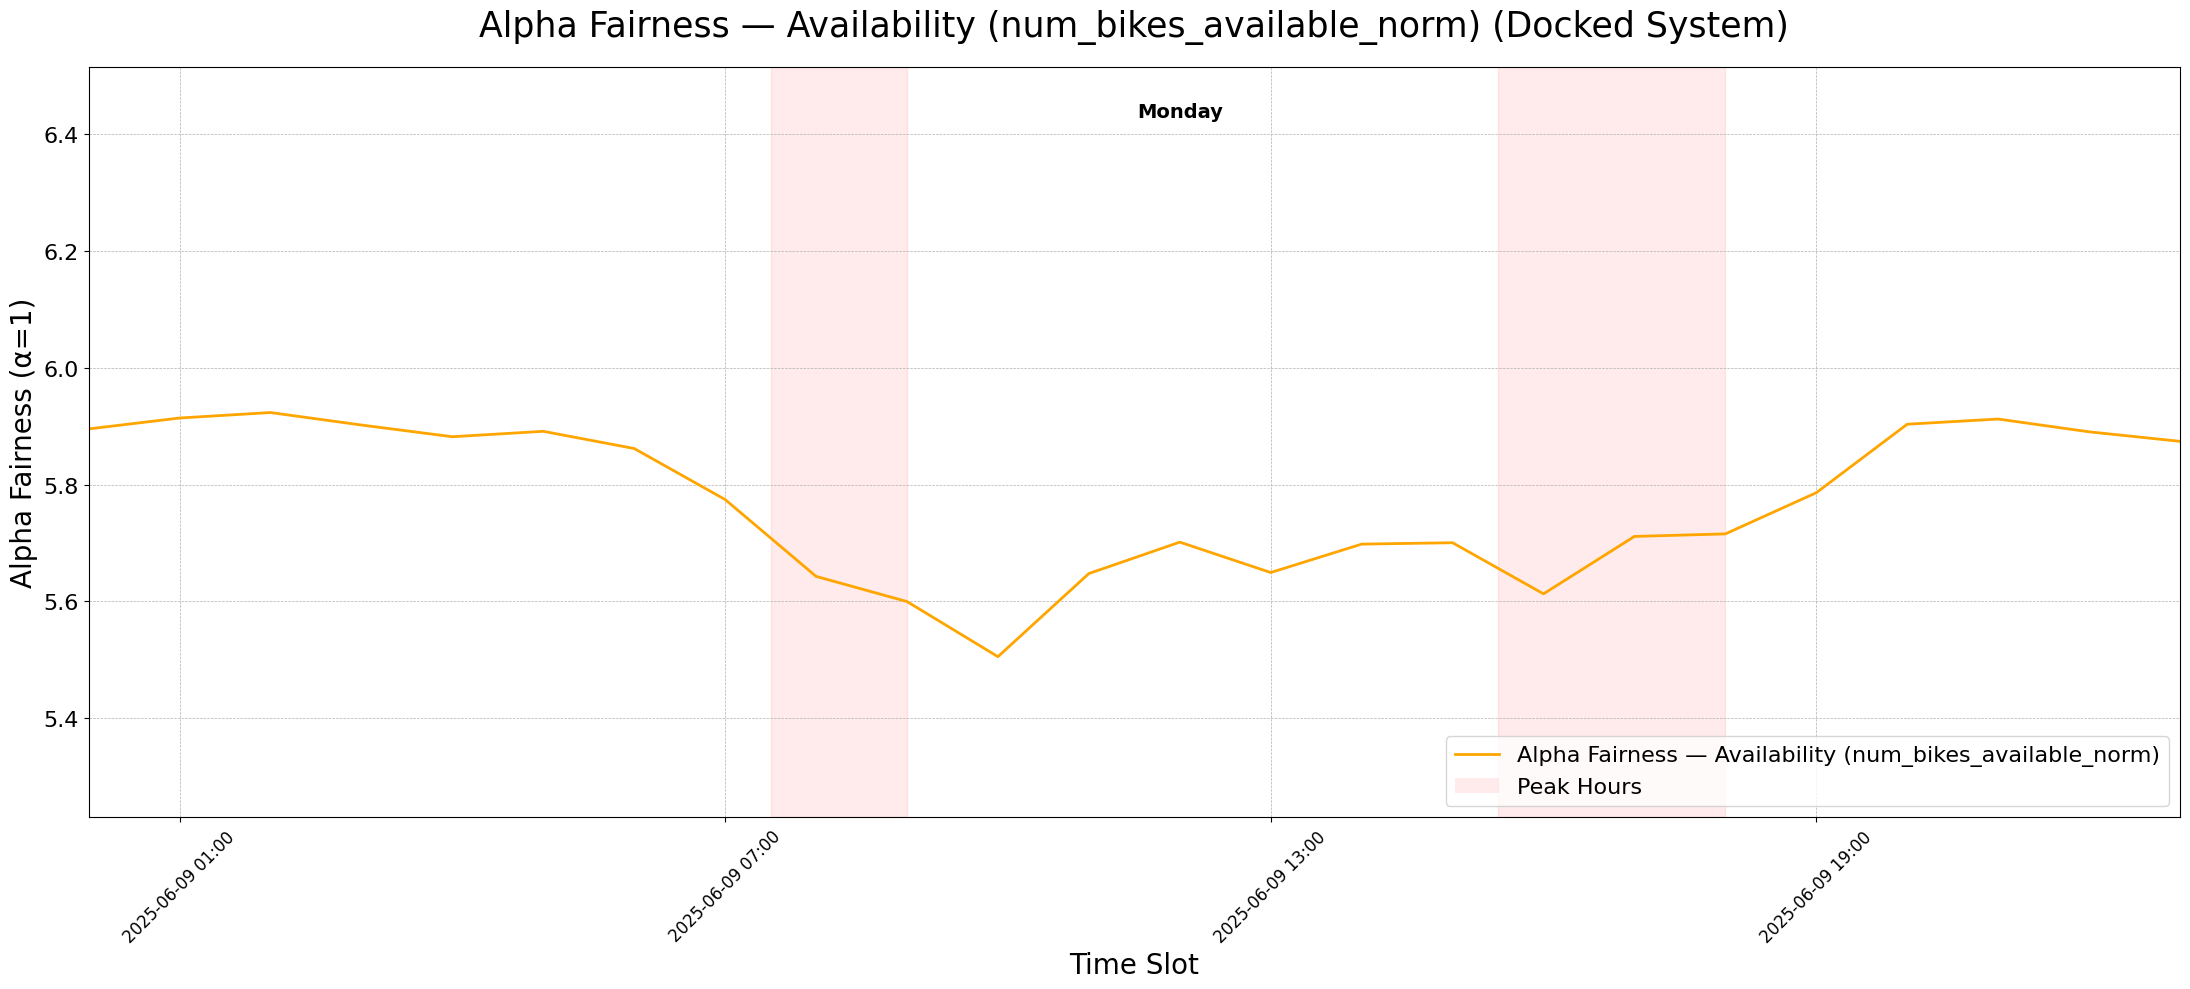

  [Availability] Plots saved for: Availability (num_bikes_available_norm)


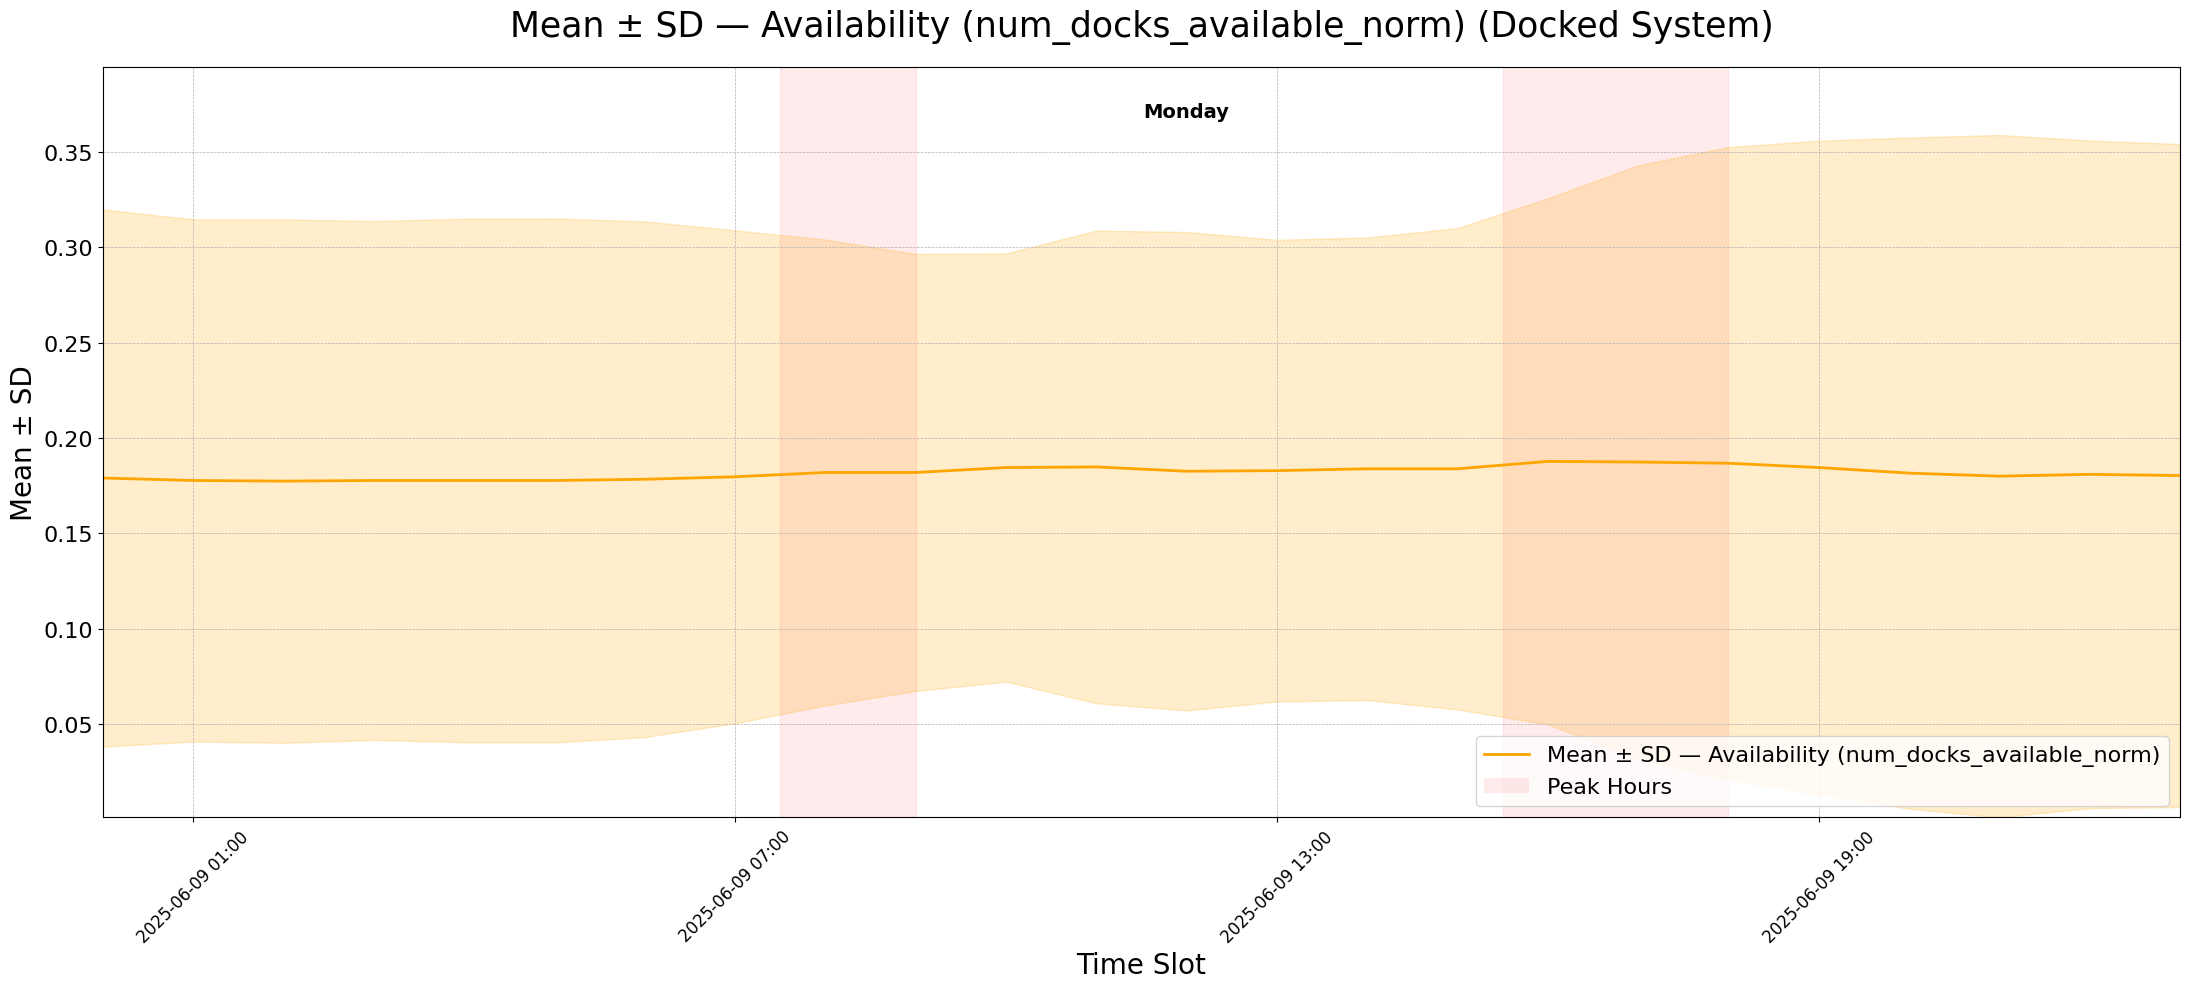

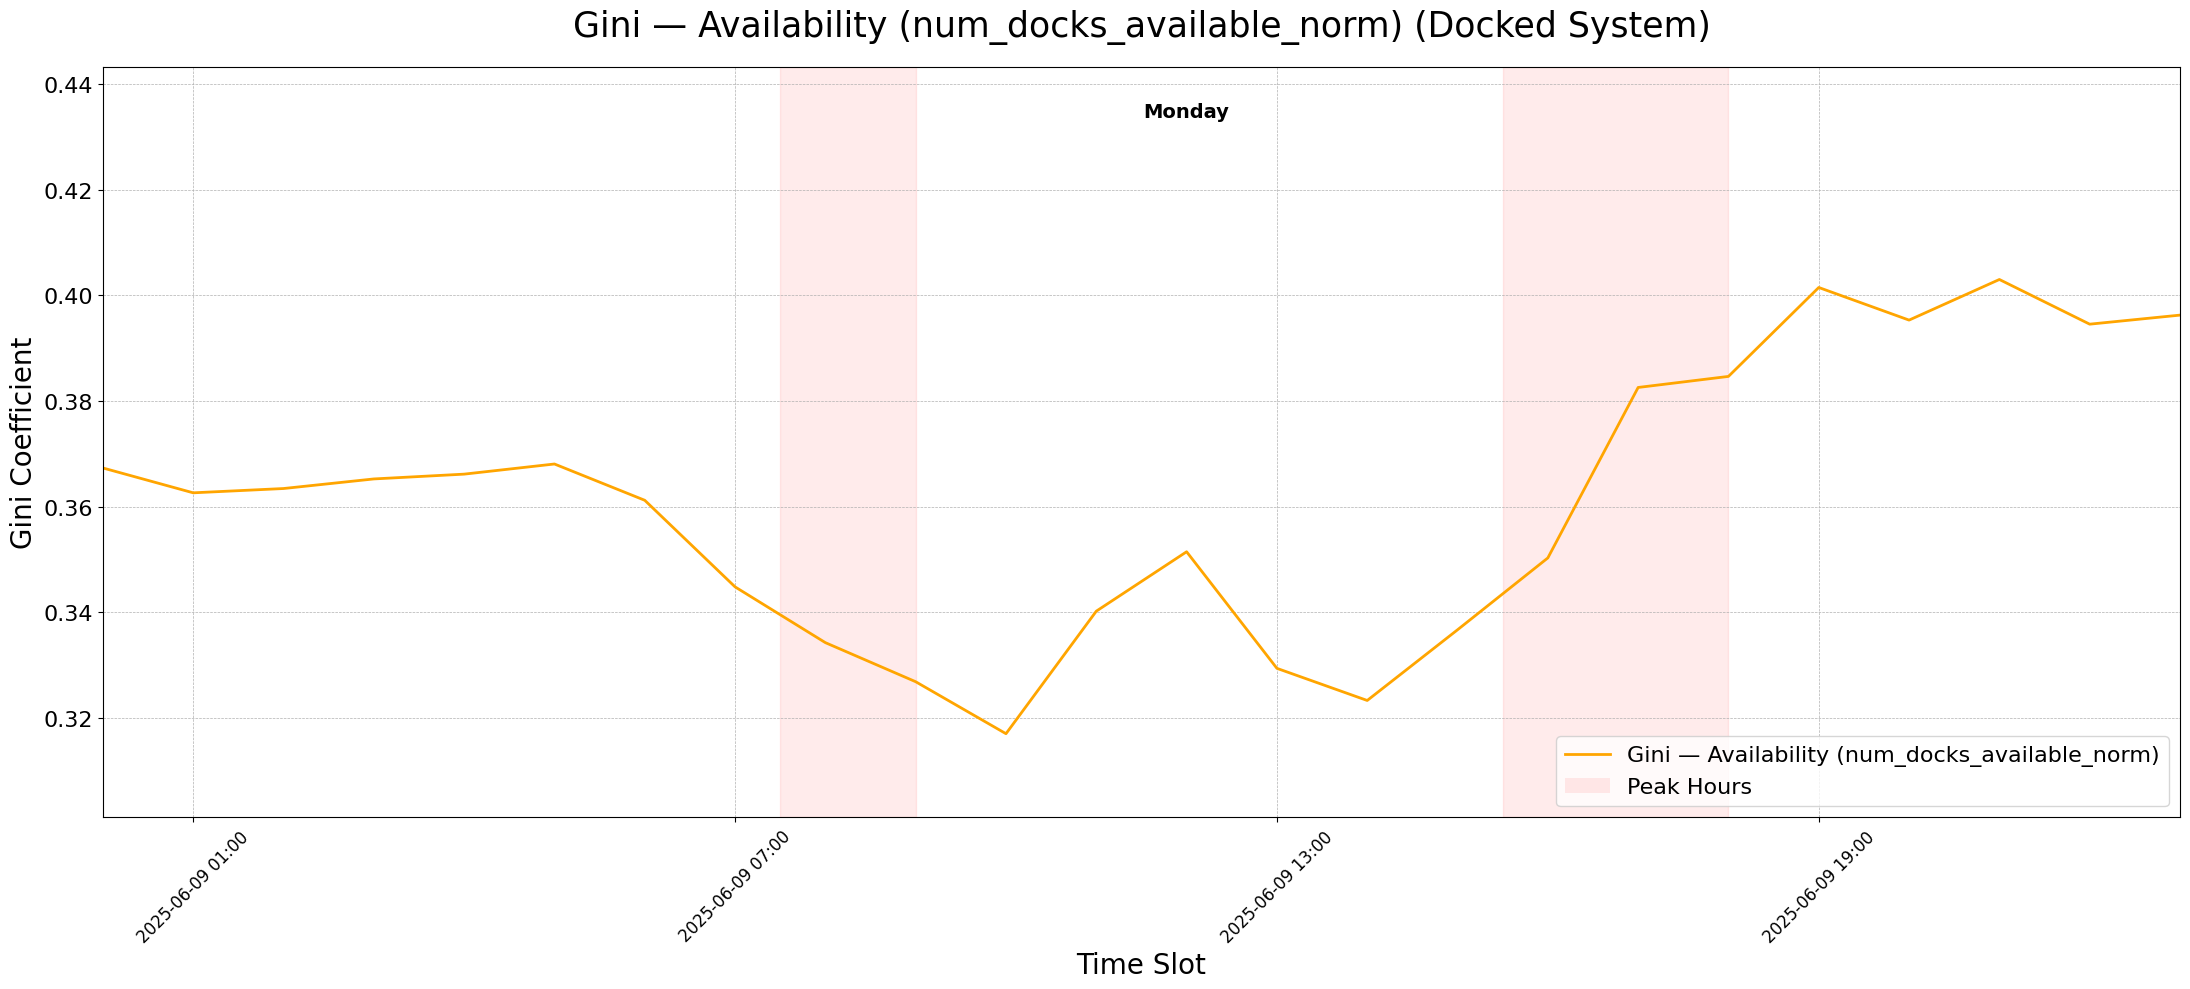

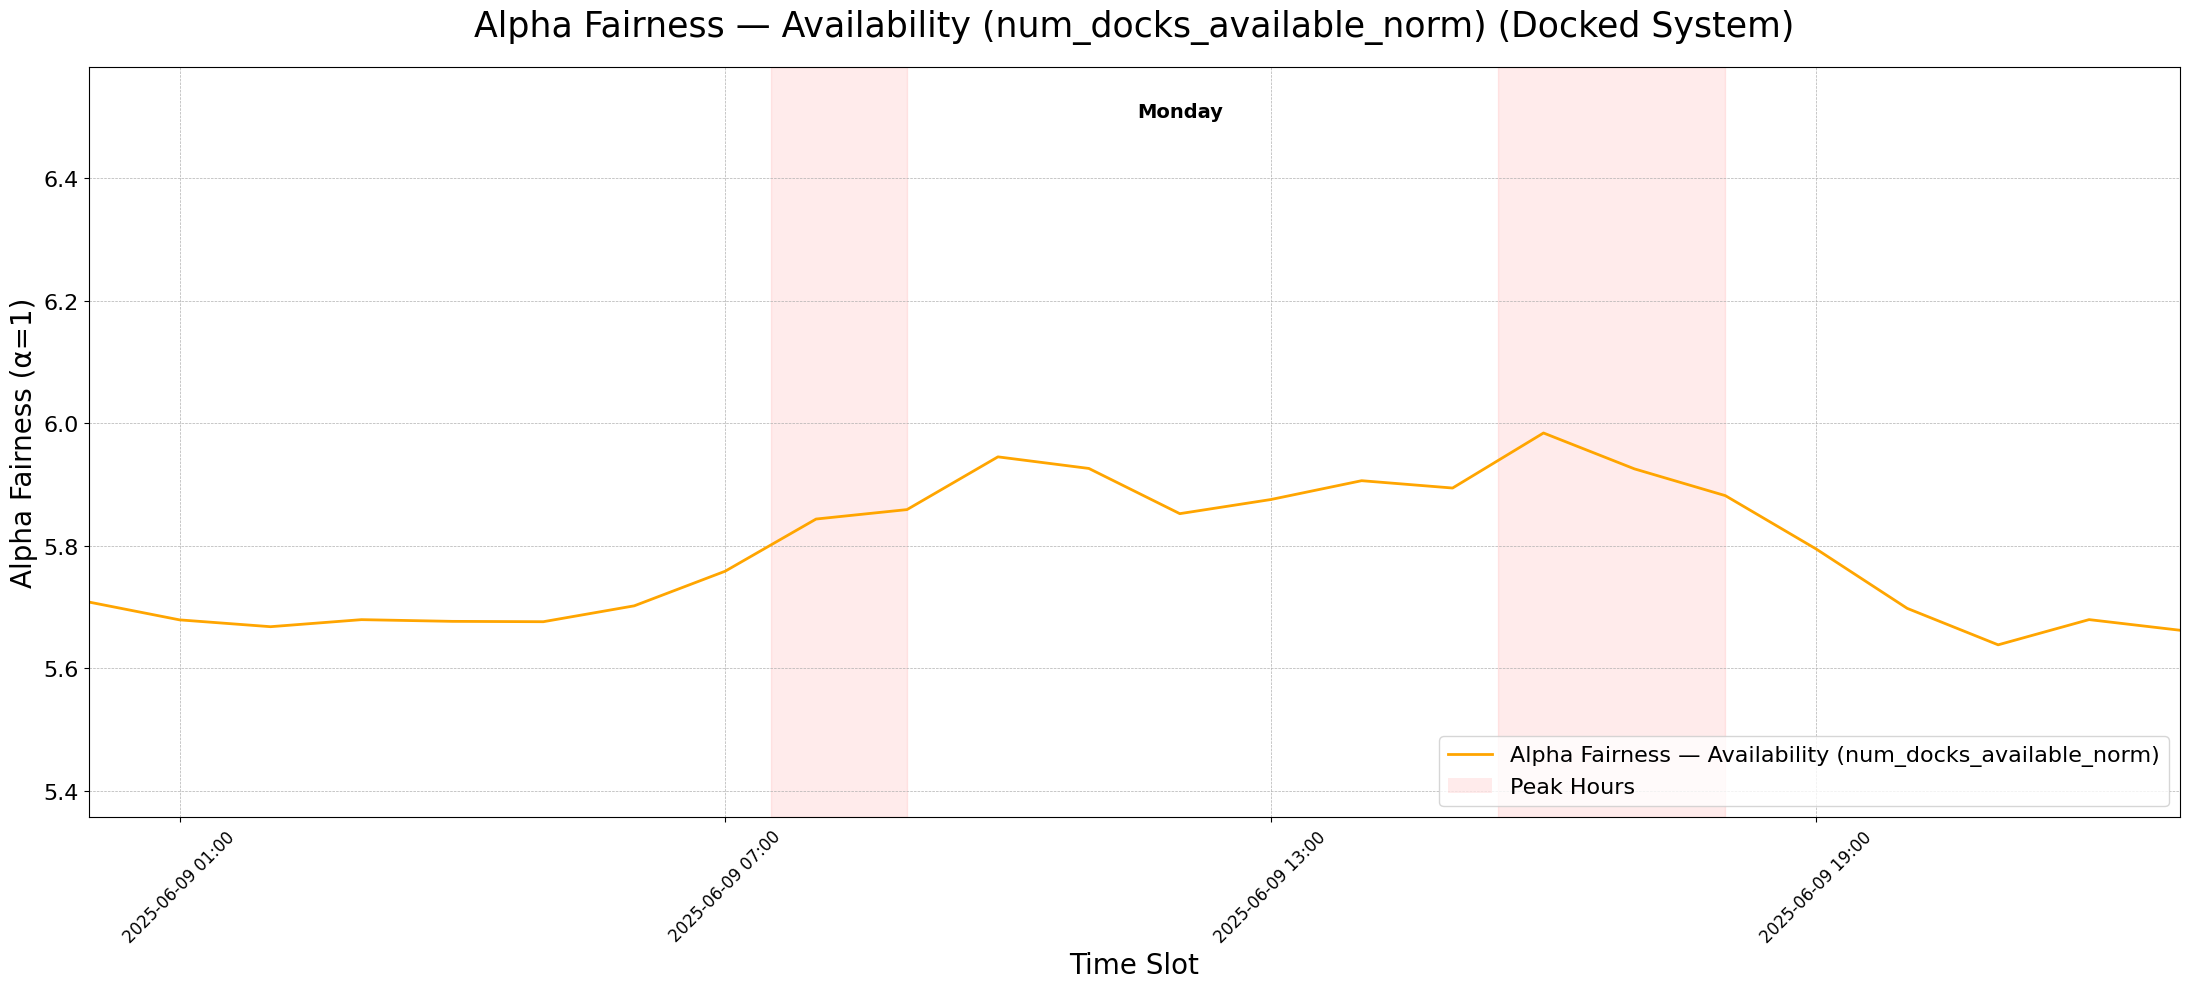

  [Availability] Plots saved for: Availability (num_docks_available_norm)


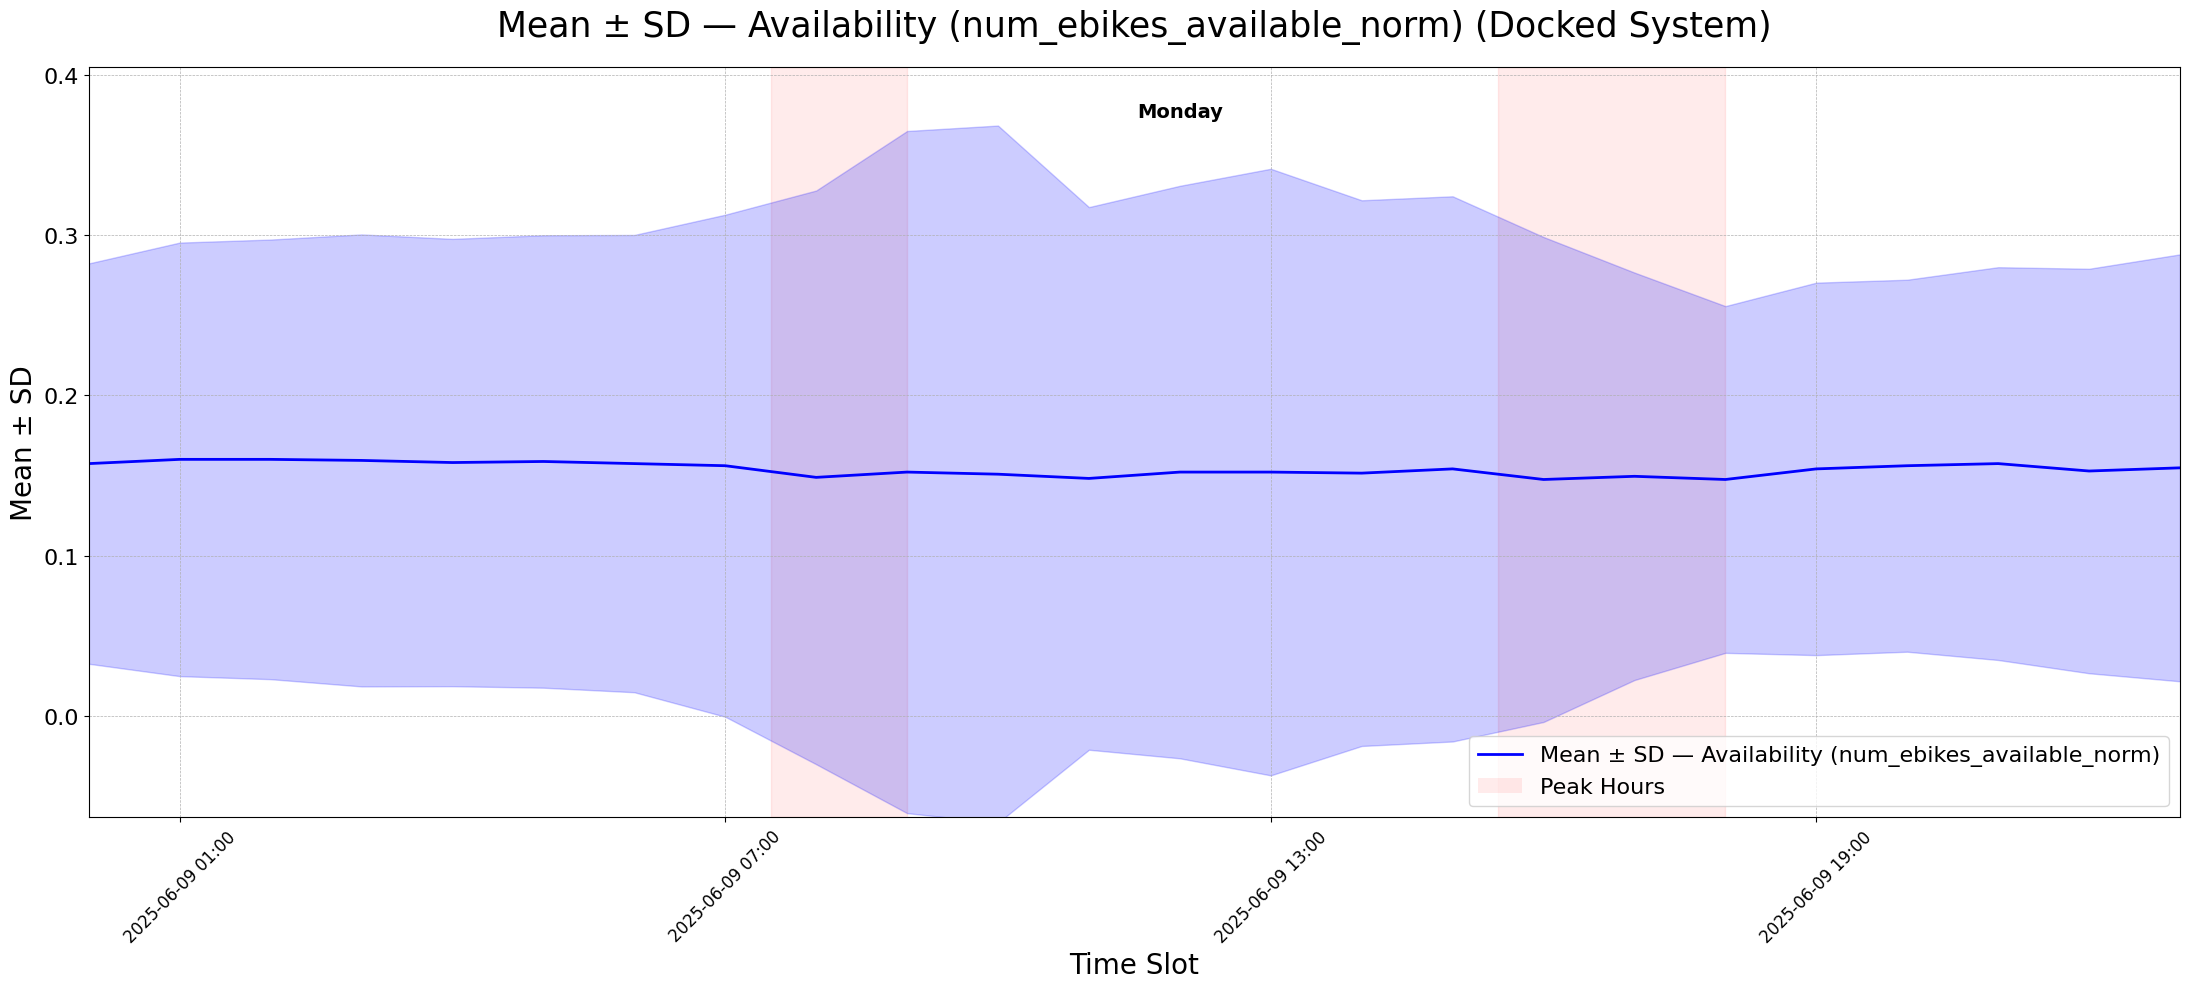

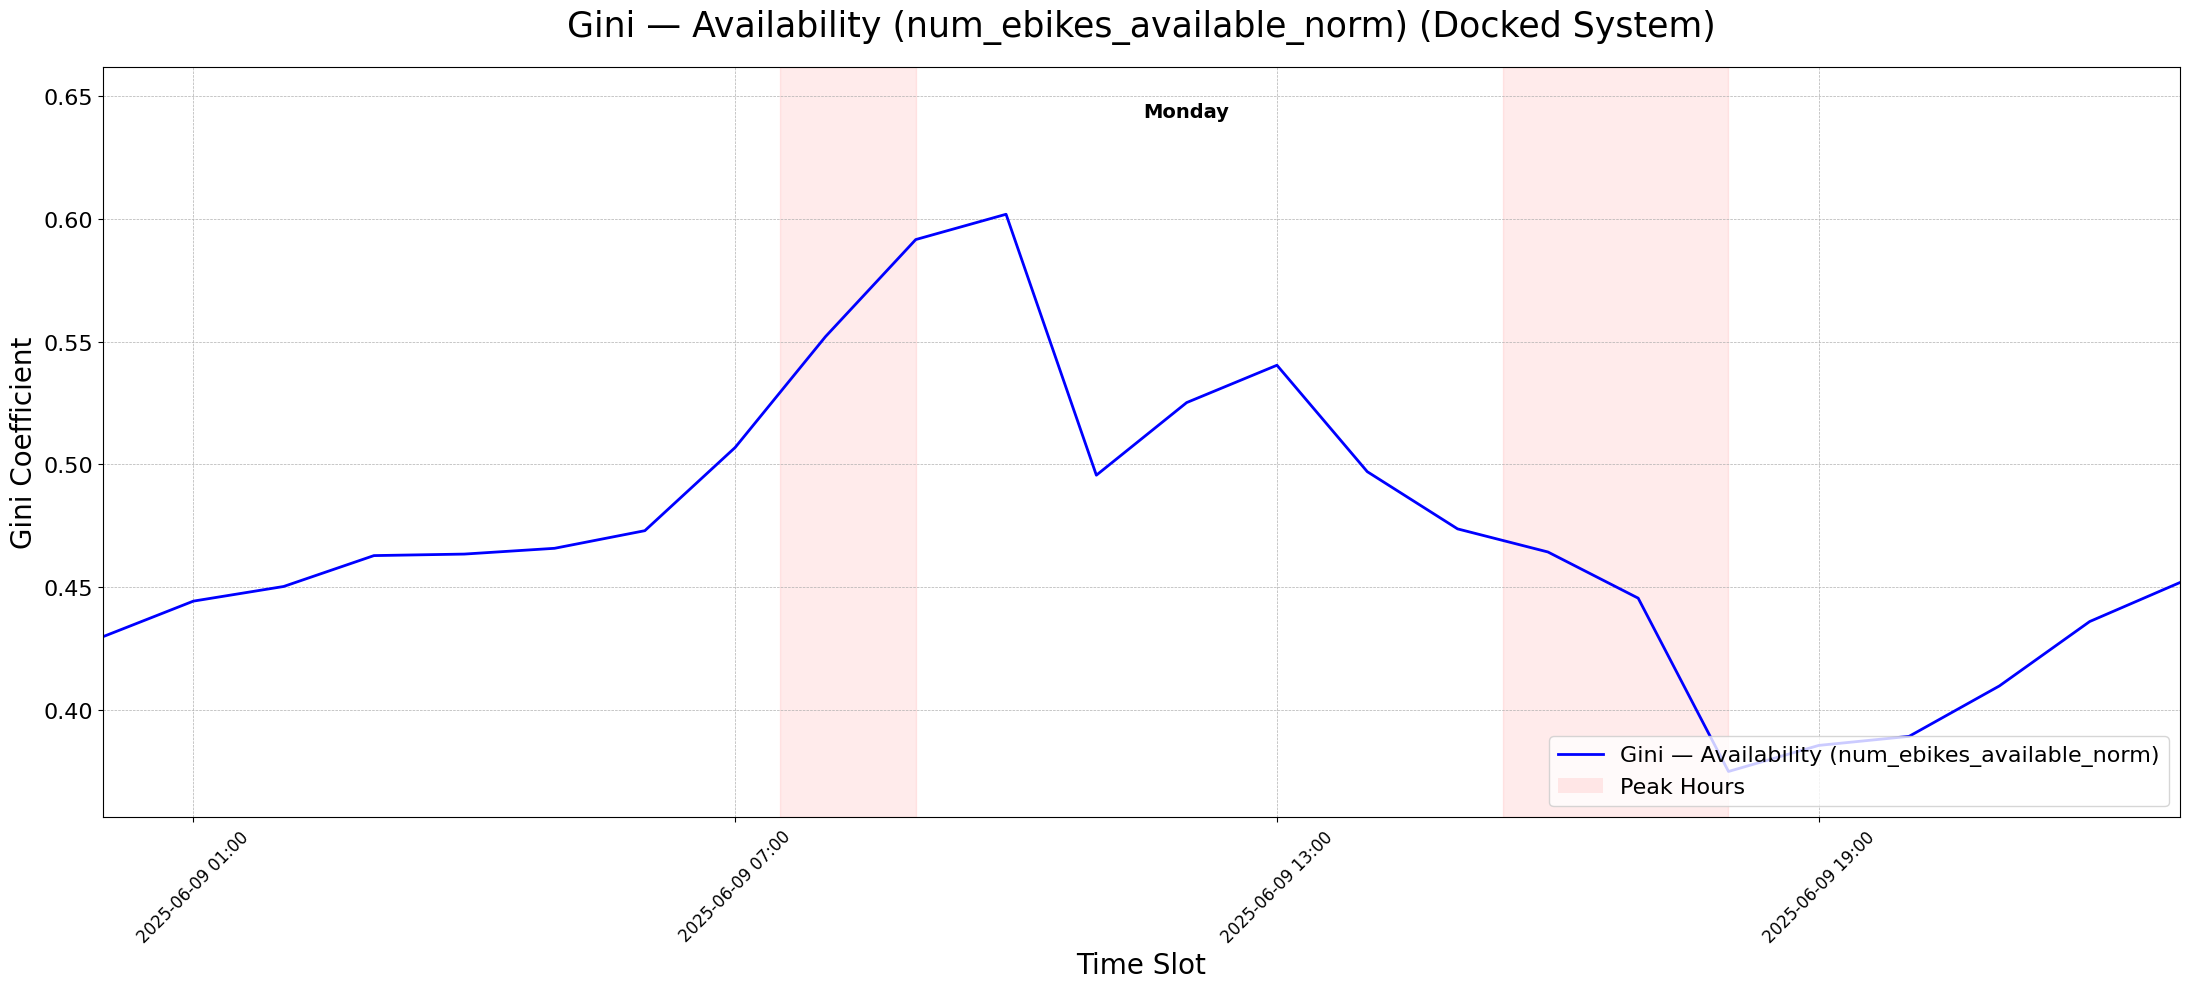

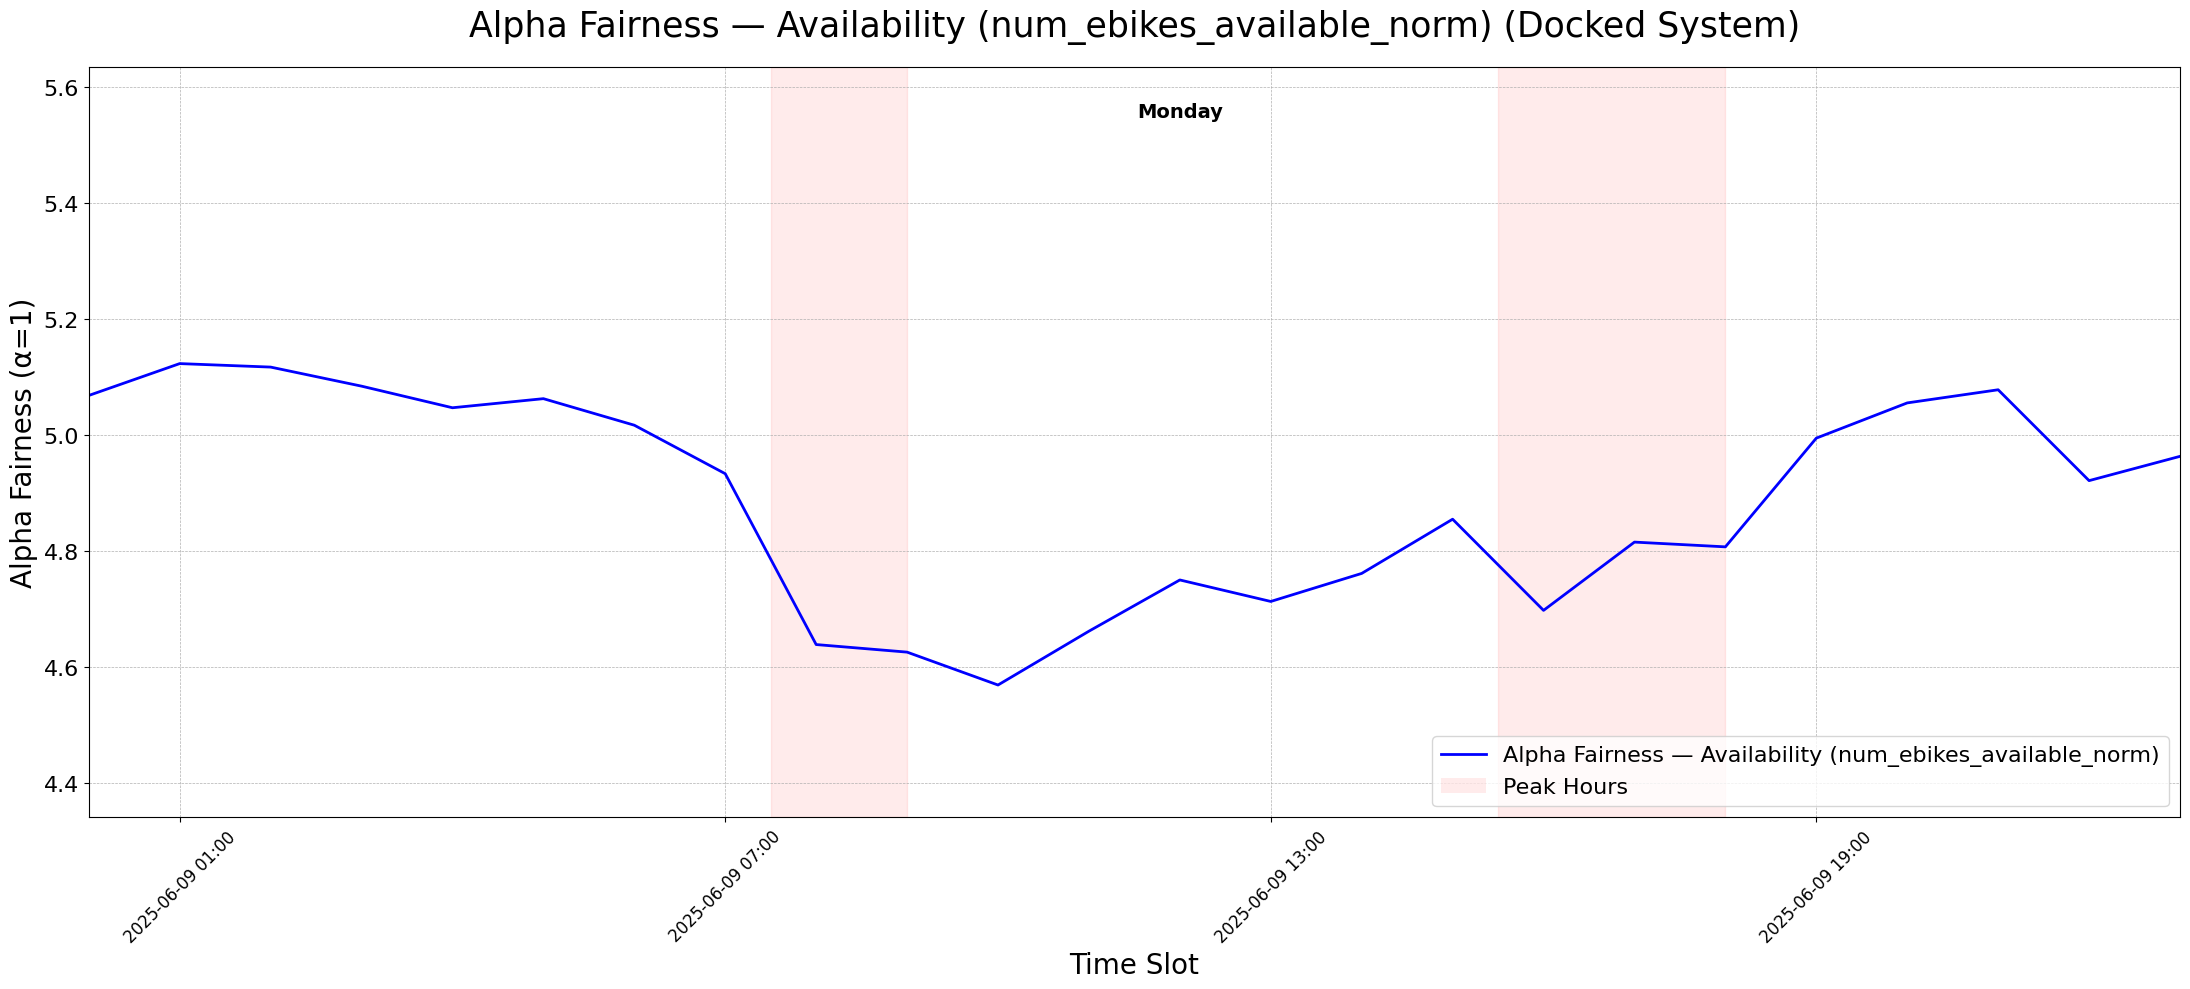

  [Availability] Plots saved for: Availability (num_ebikes_available_norm)


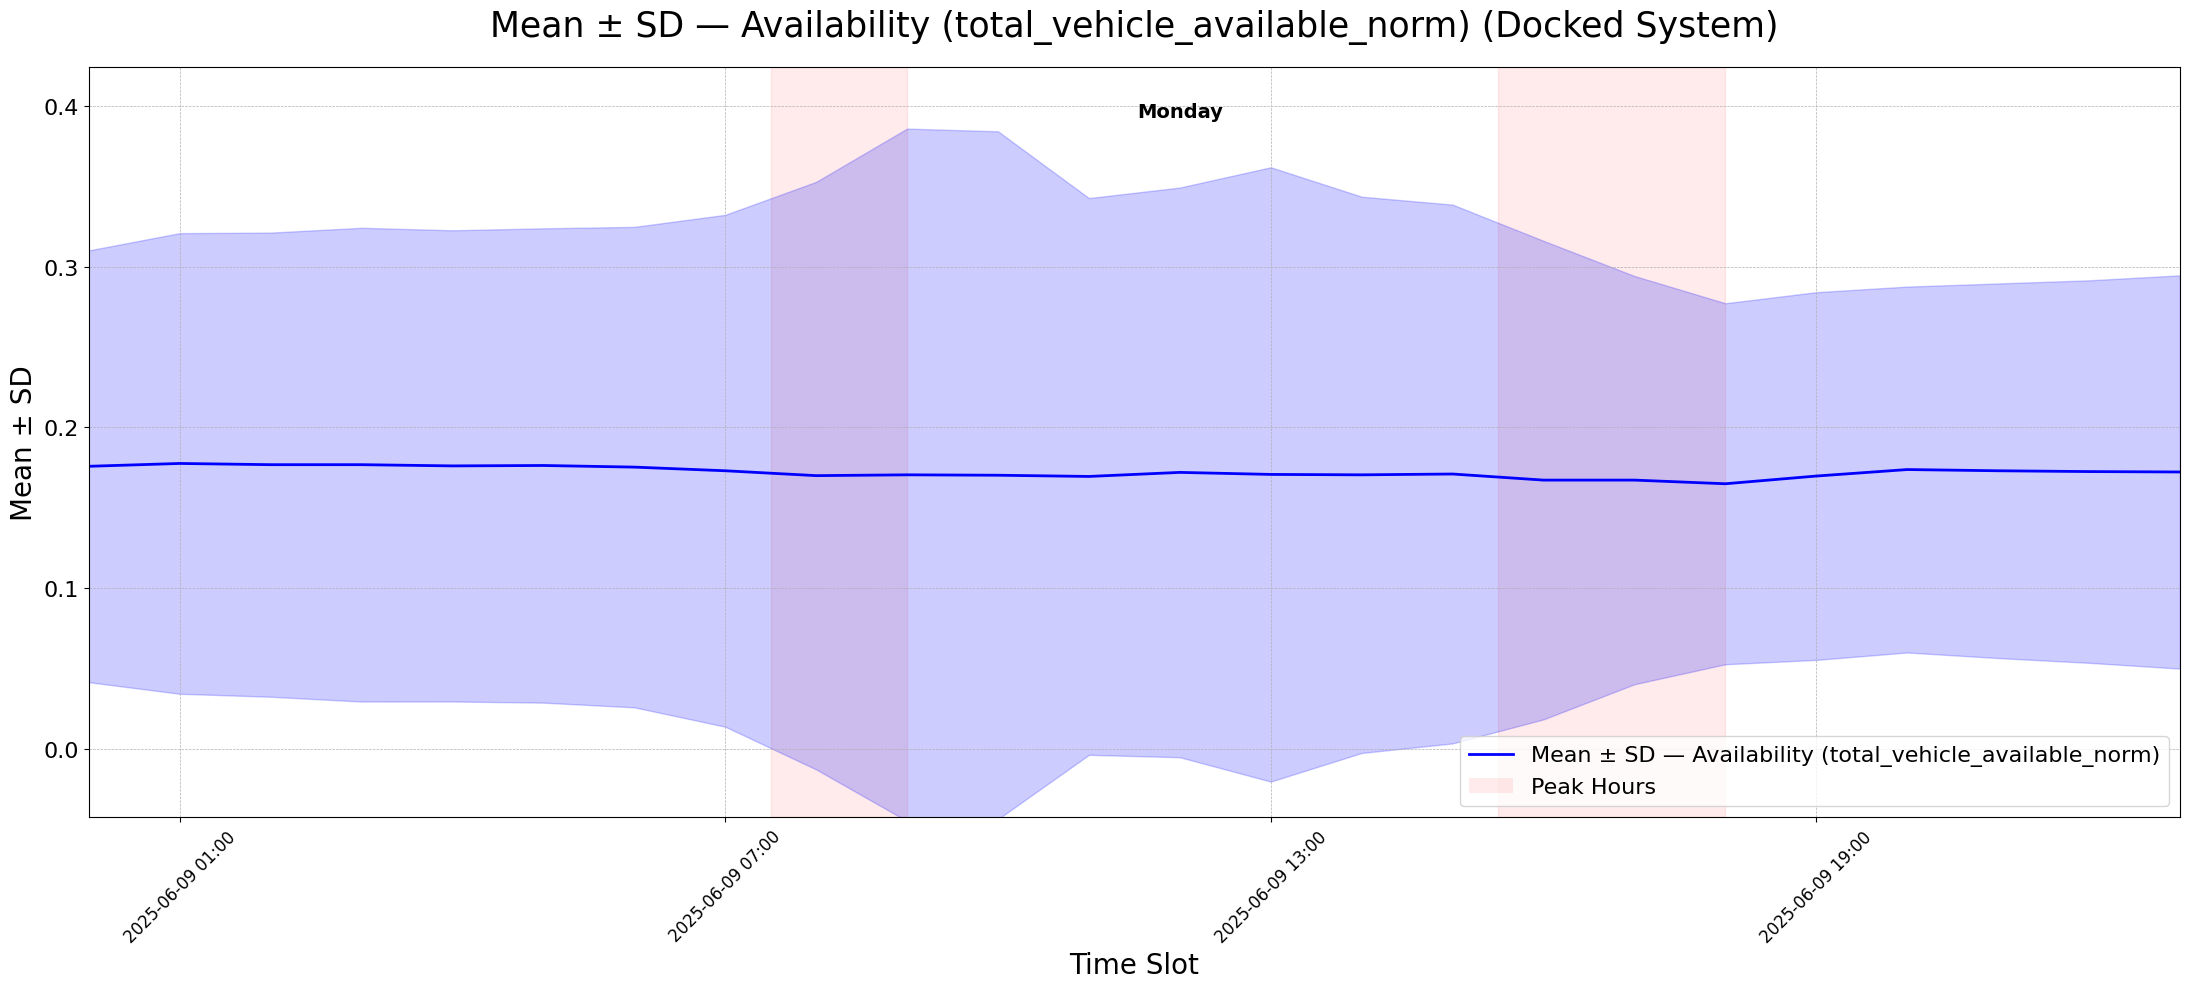

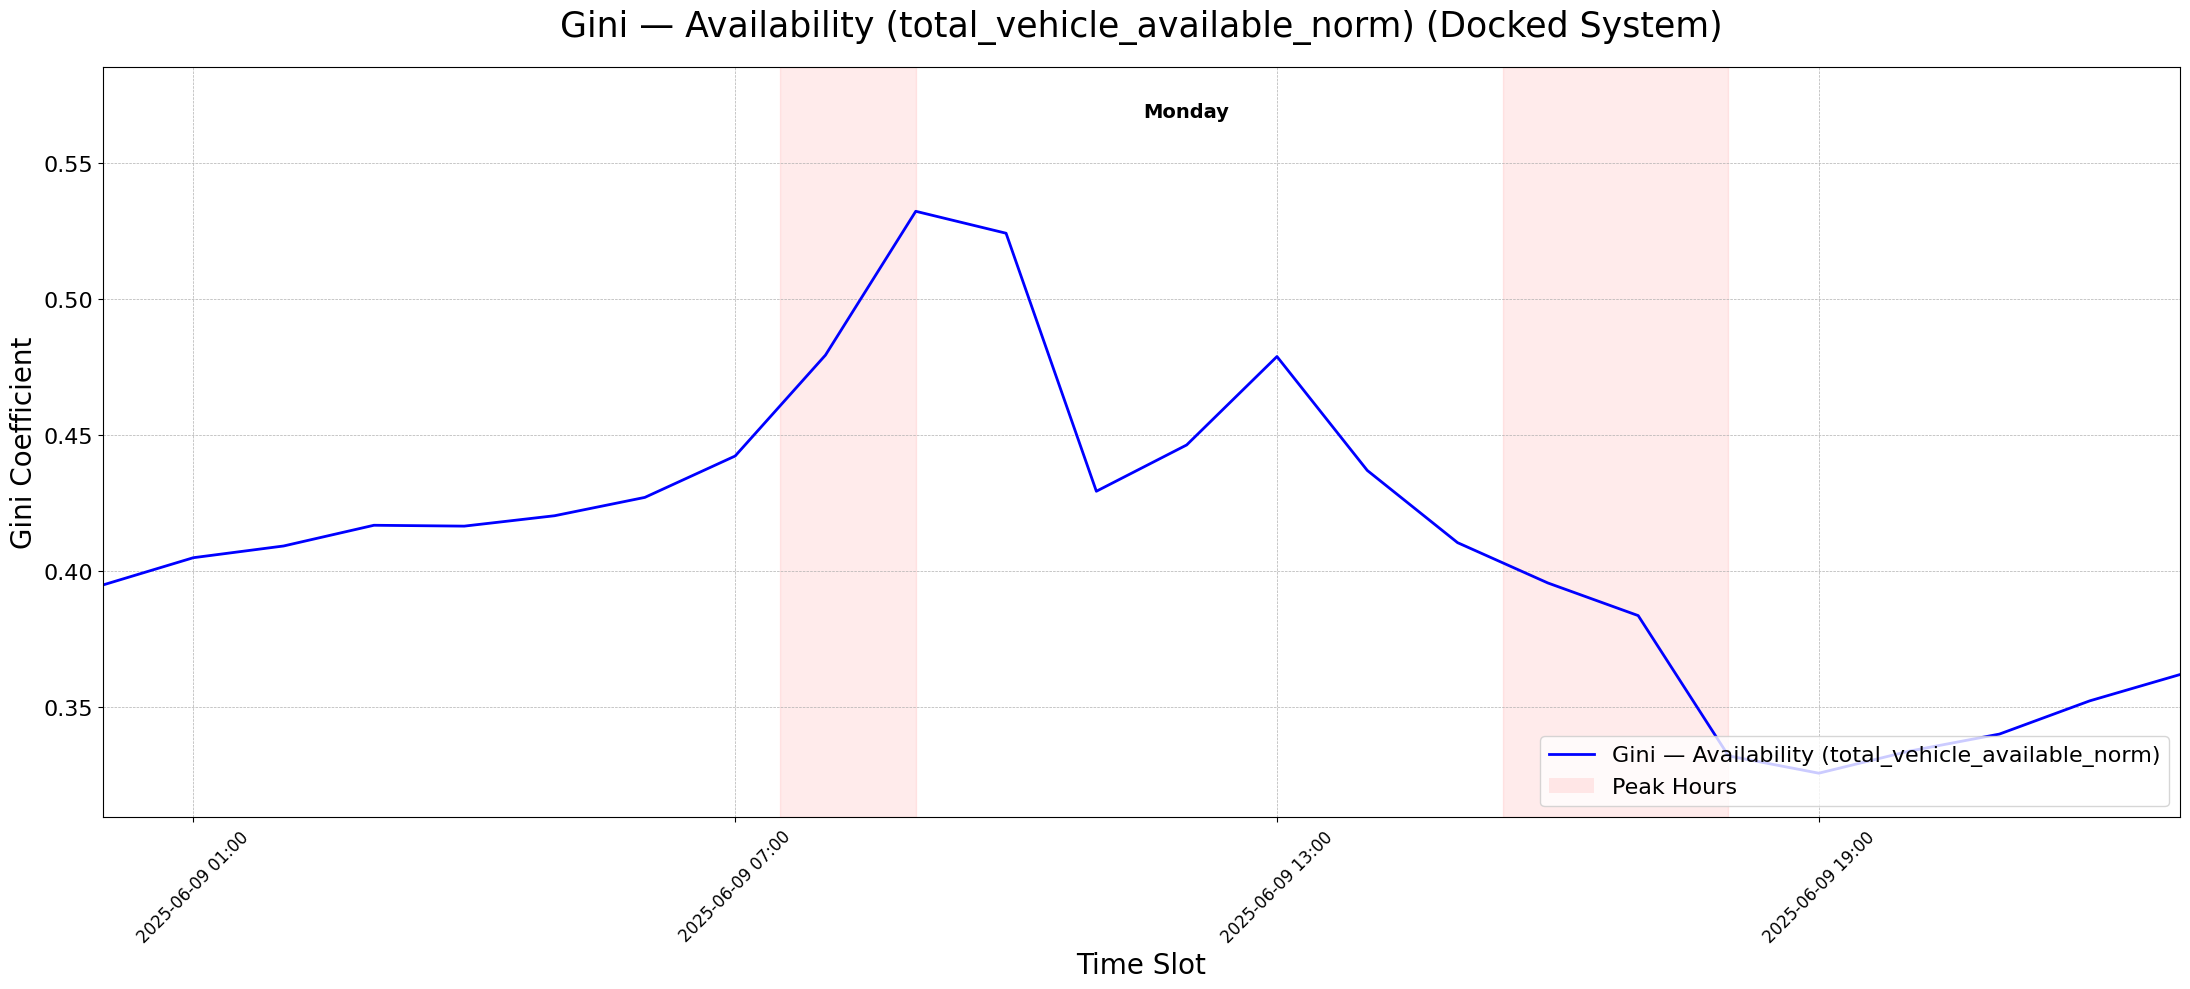

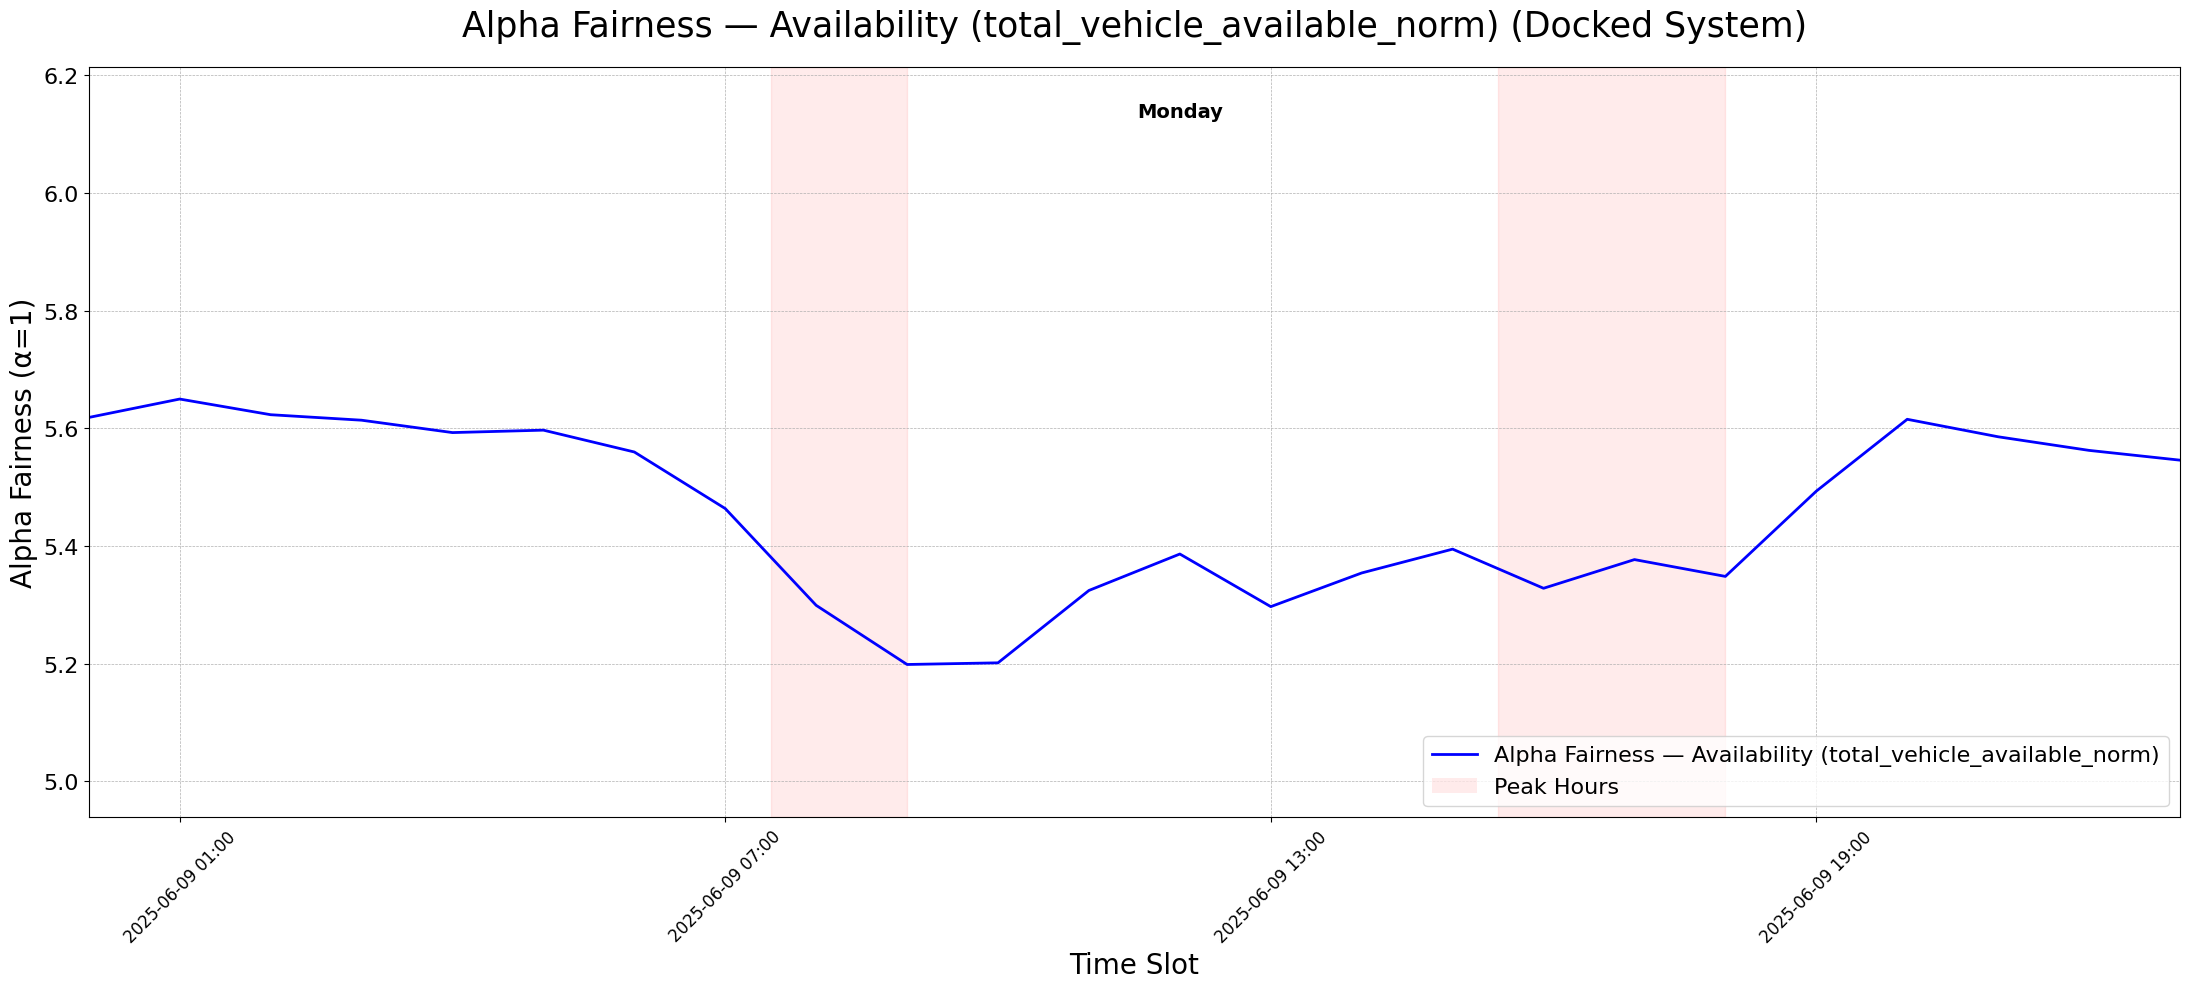

  [Availability] Plots saved for: Availability (total_vehicle_available_norm)
  [Usage] Fairness CSV saved: PITT_OUTPUT\TREND\PITT_DOCKED__usage_trend.csv


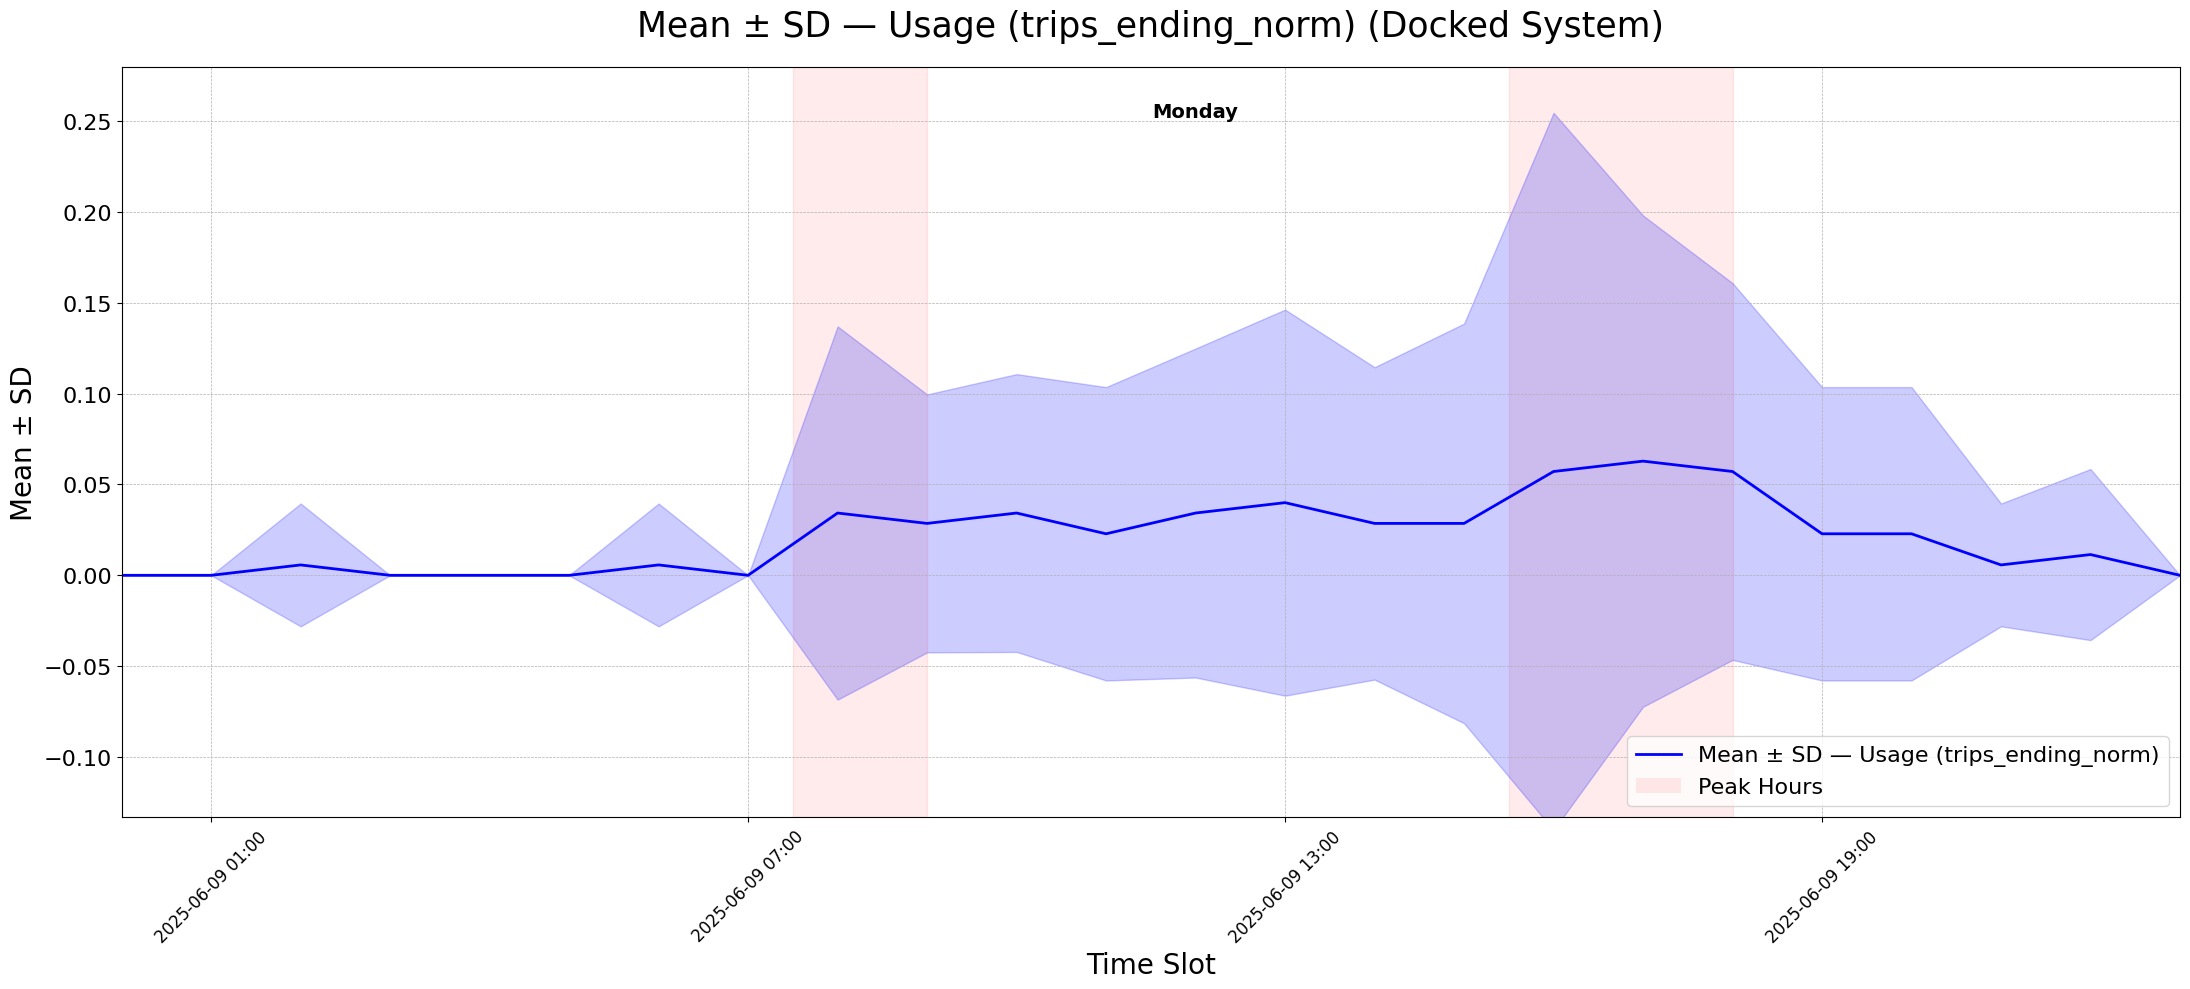

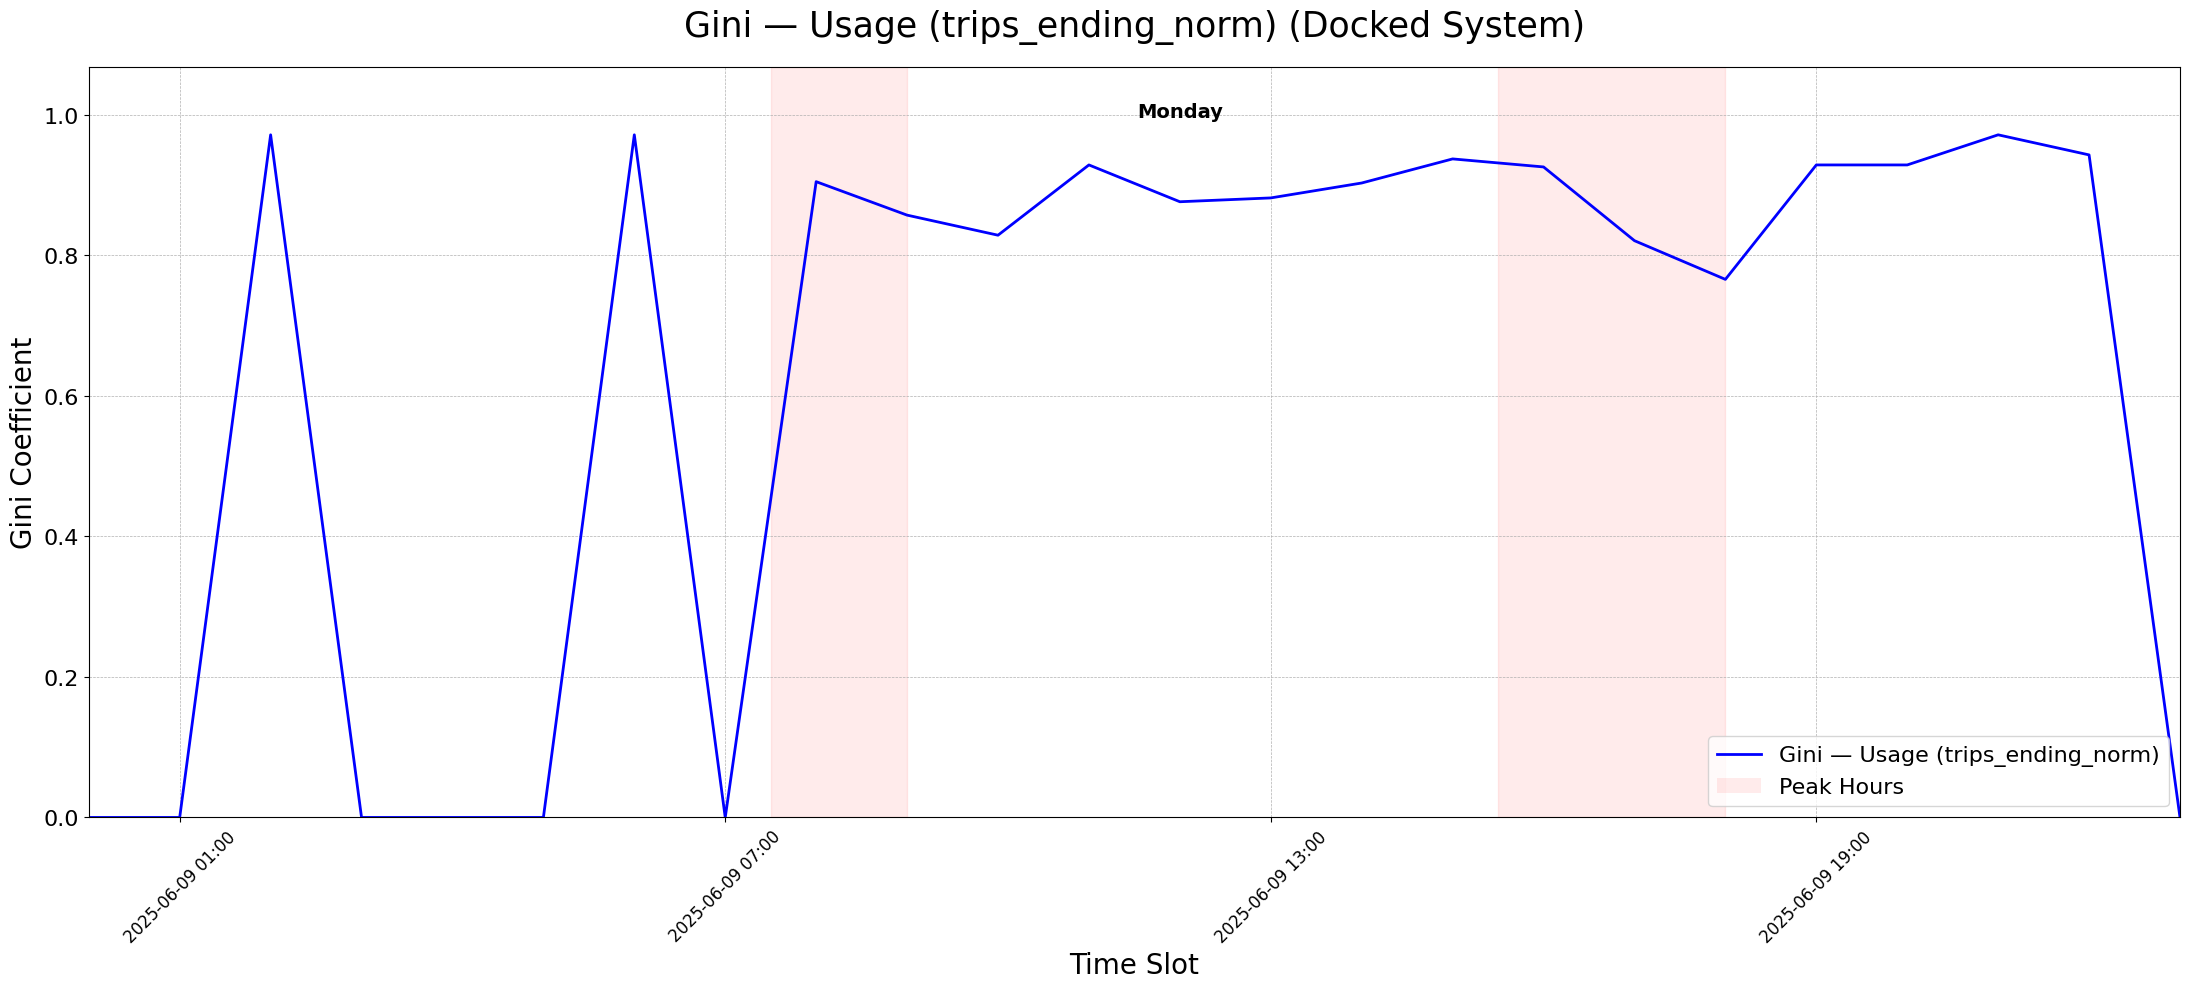

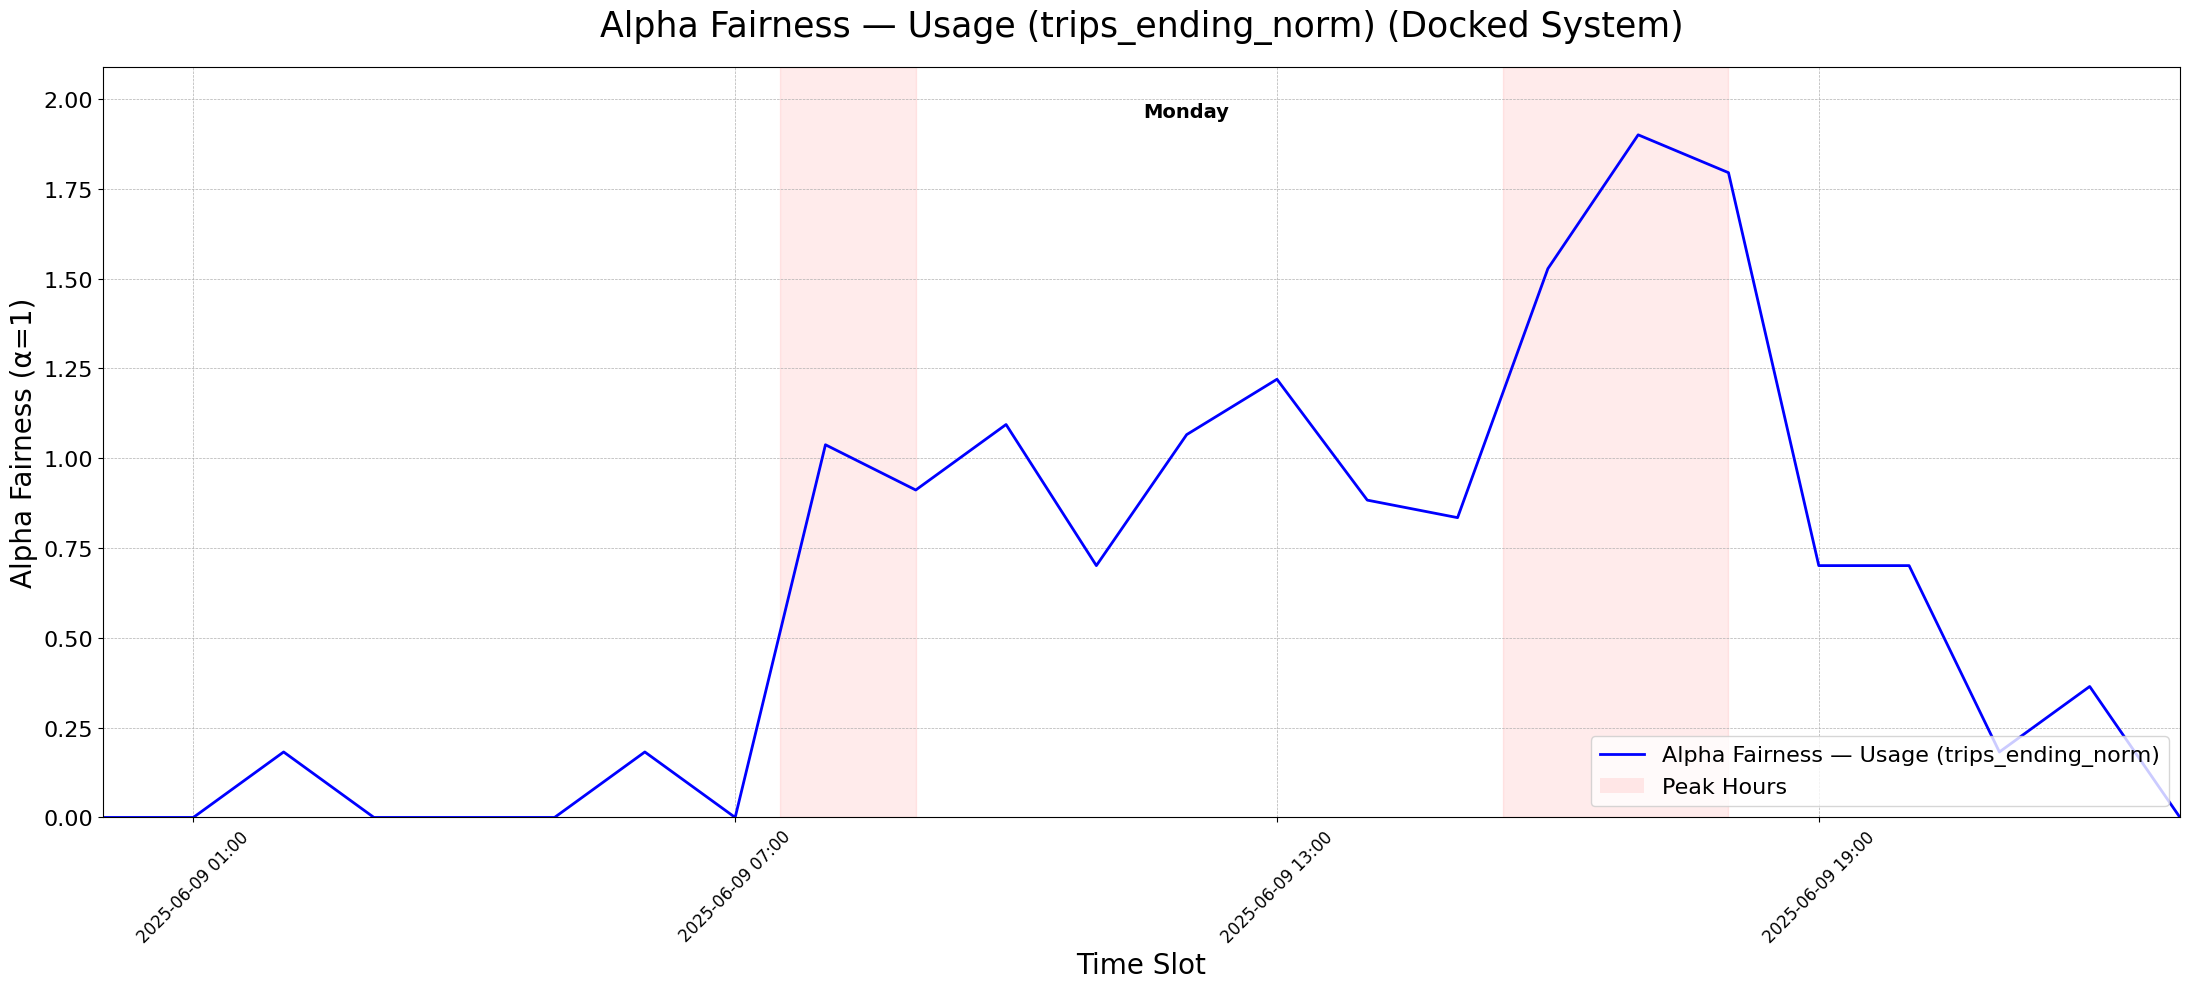

  [Usage] Plots saved for: Usage (trips_ending_norm)


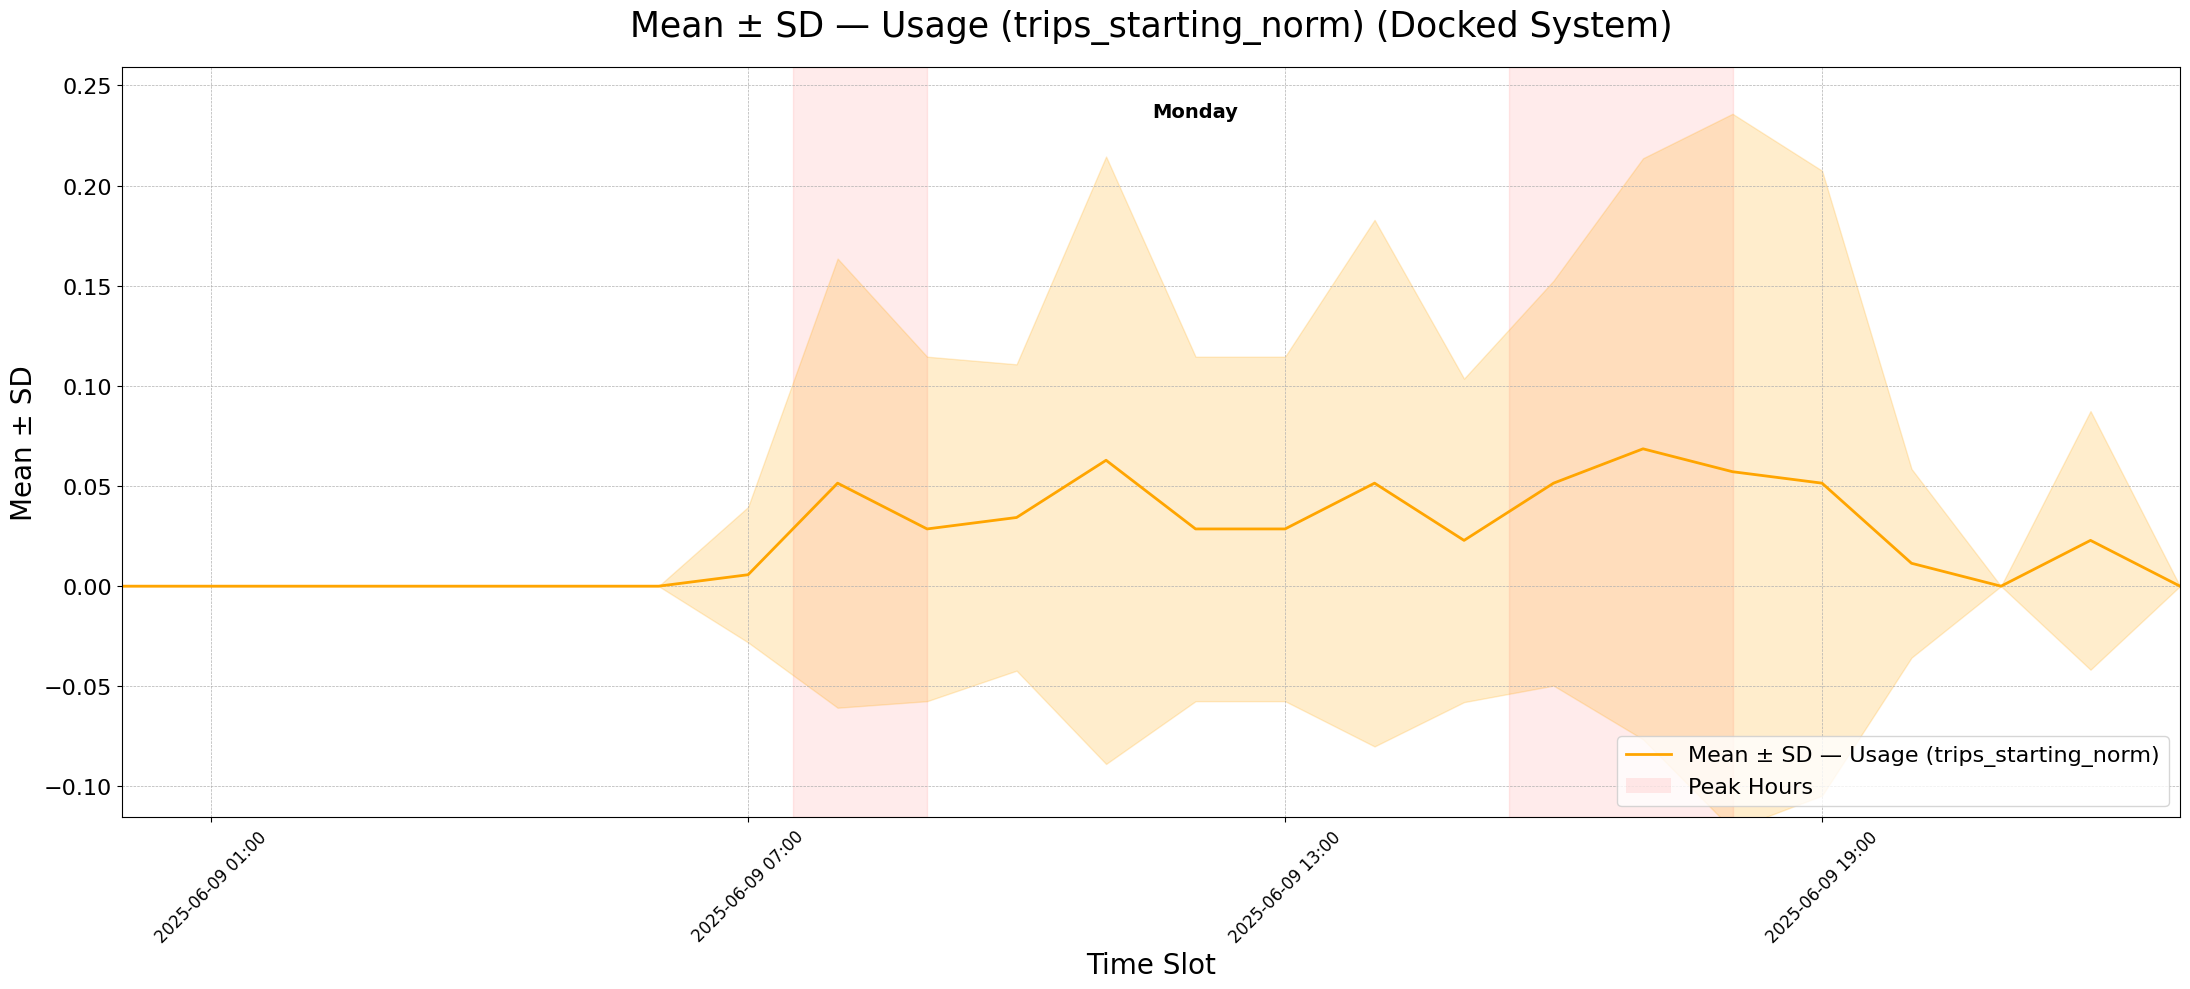

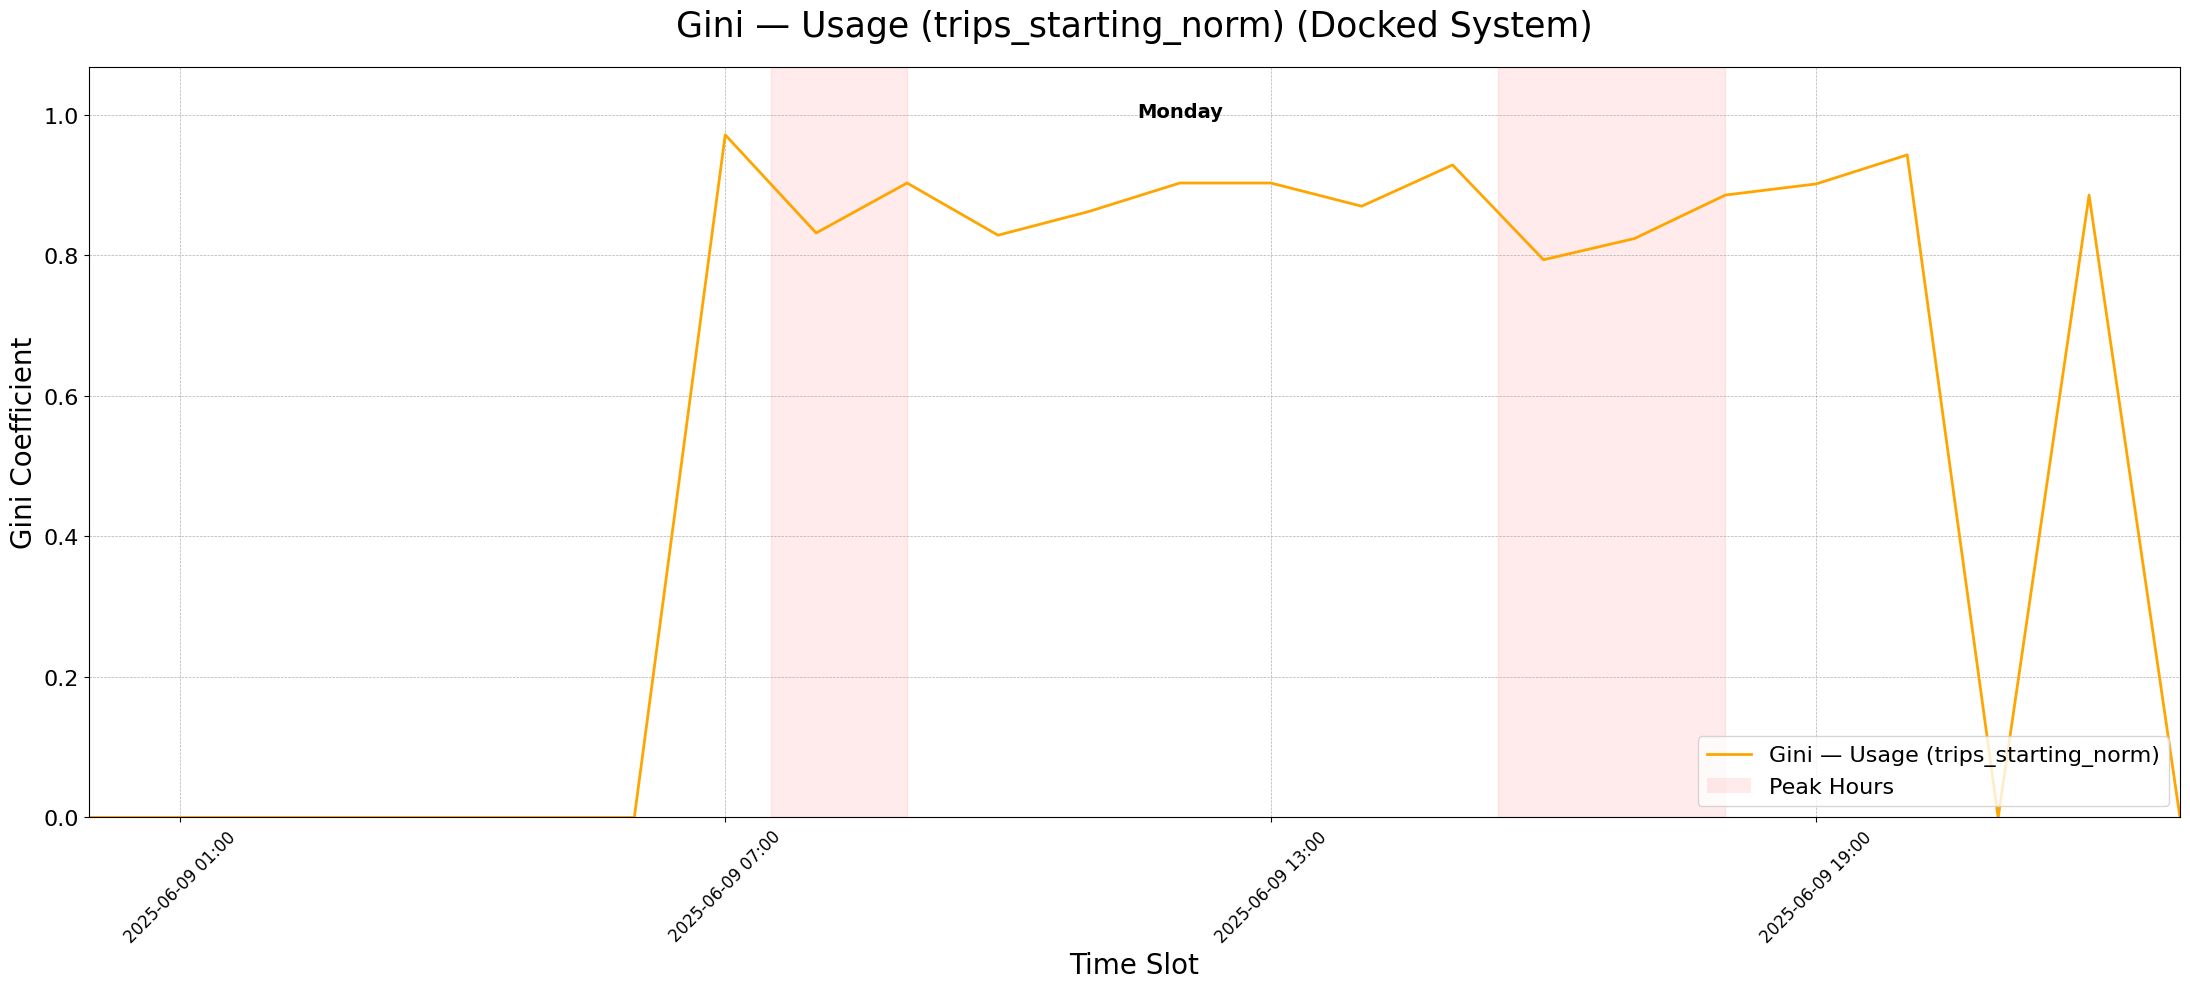

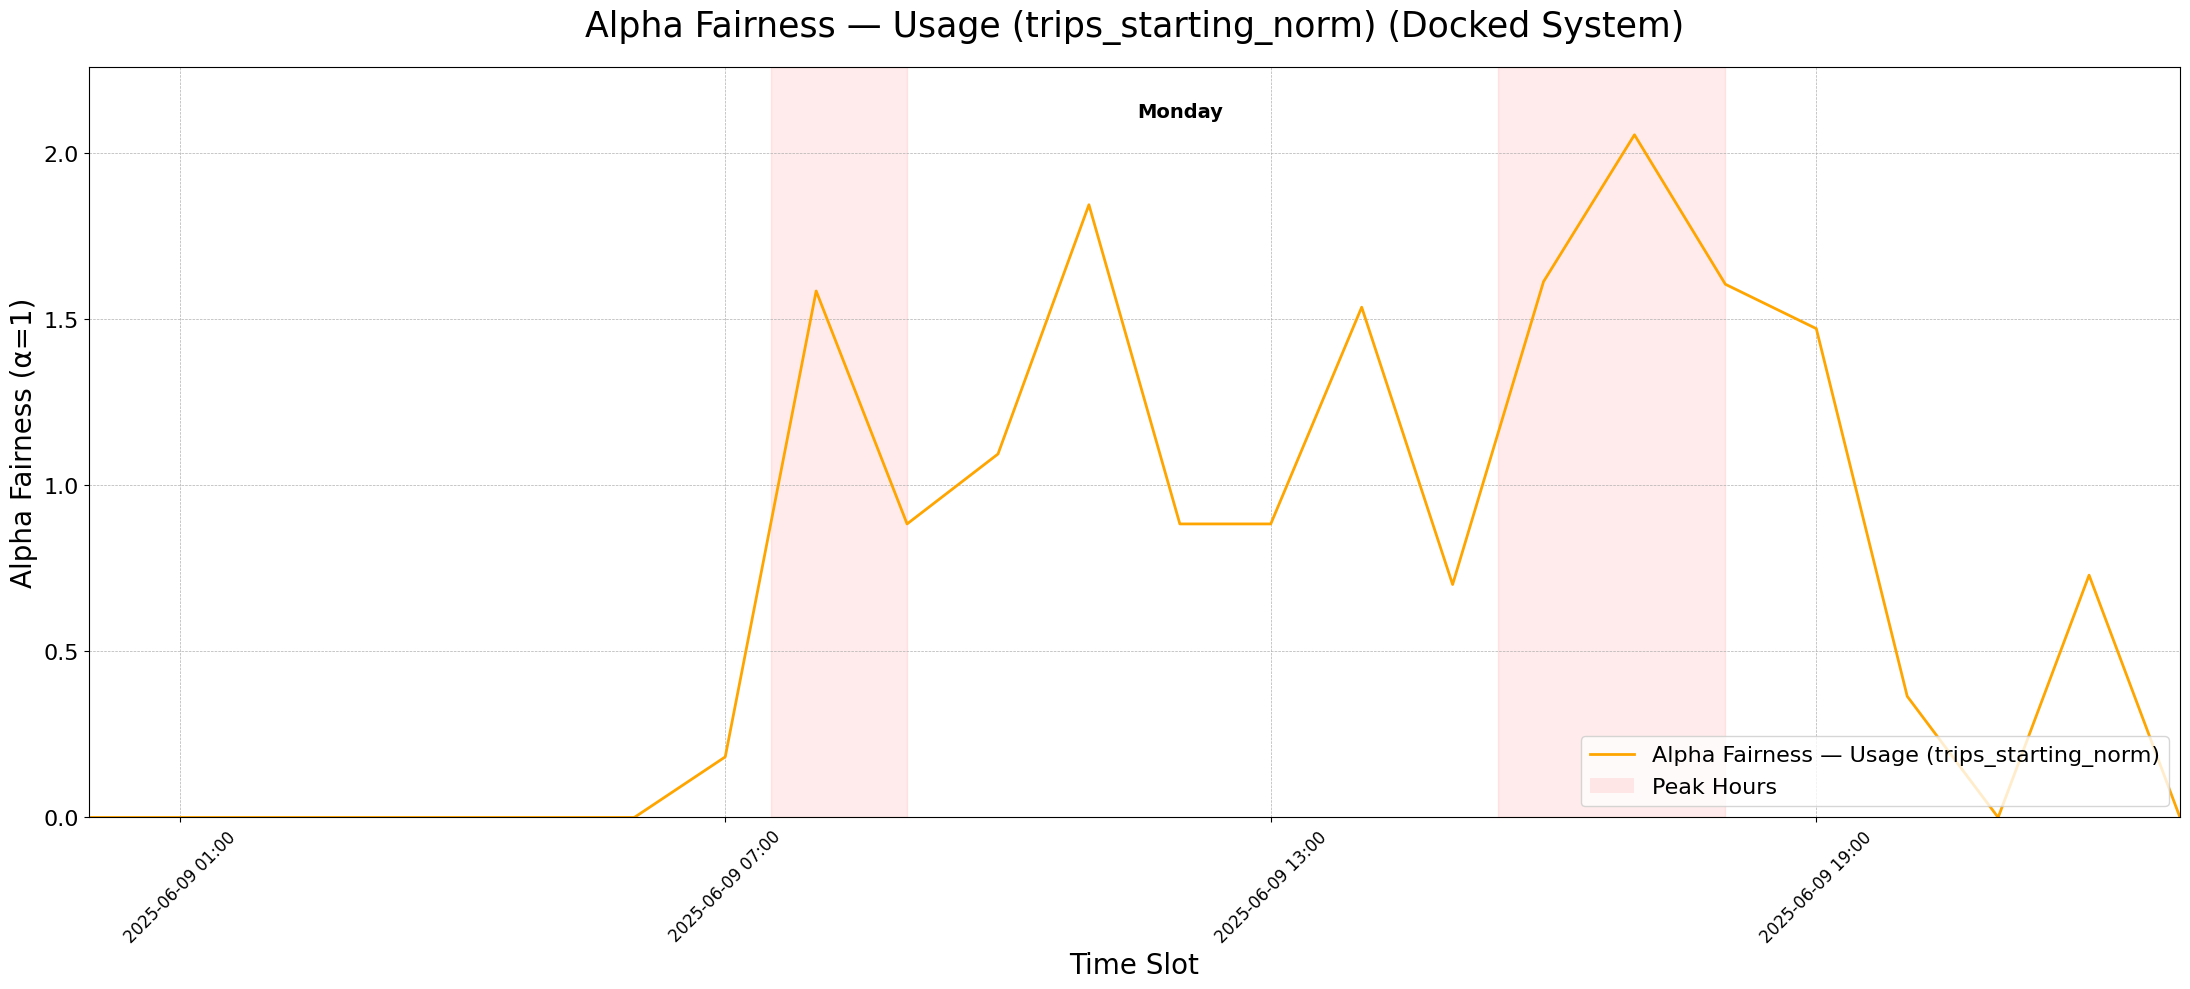

  [Usage] Plots saved for: Usage (trips_starting_norm)
  [Idle Time] Fairness CSV saved: PITT_OUTPUT\TREND\PITT_DOCKED__idle_time_trend.csv


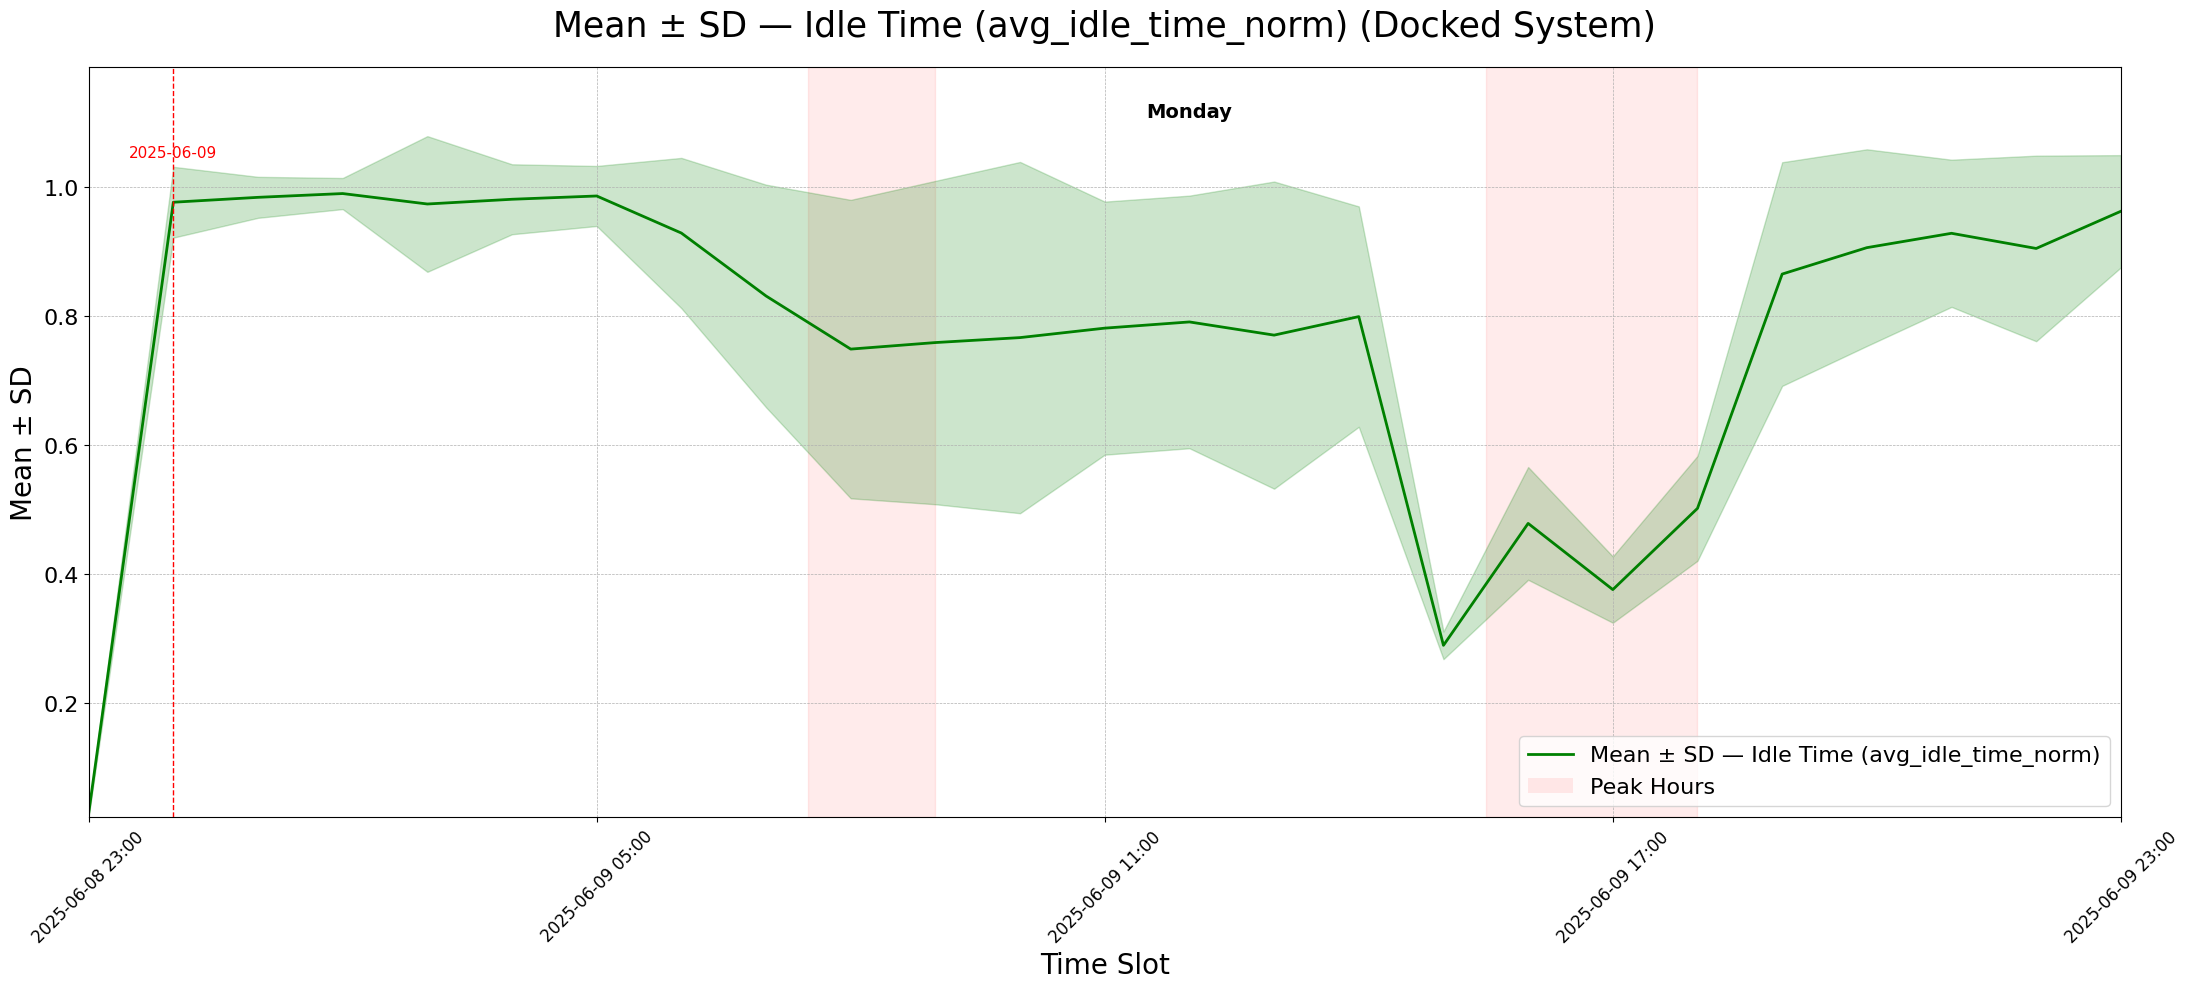

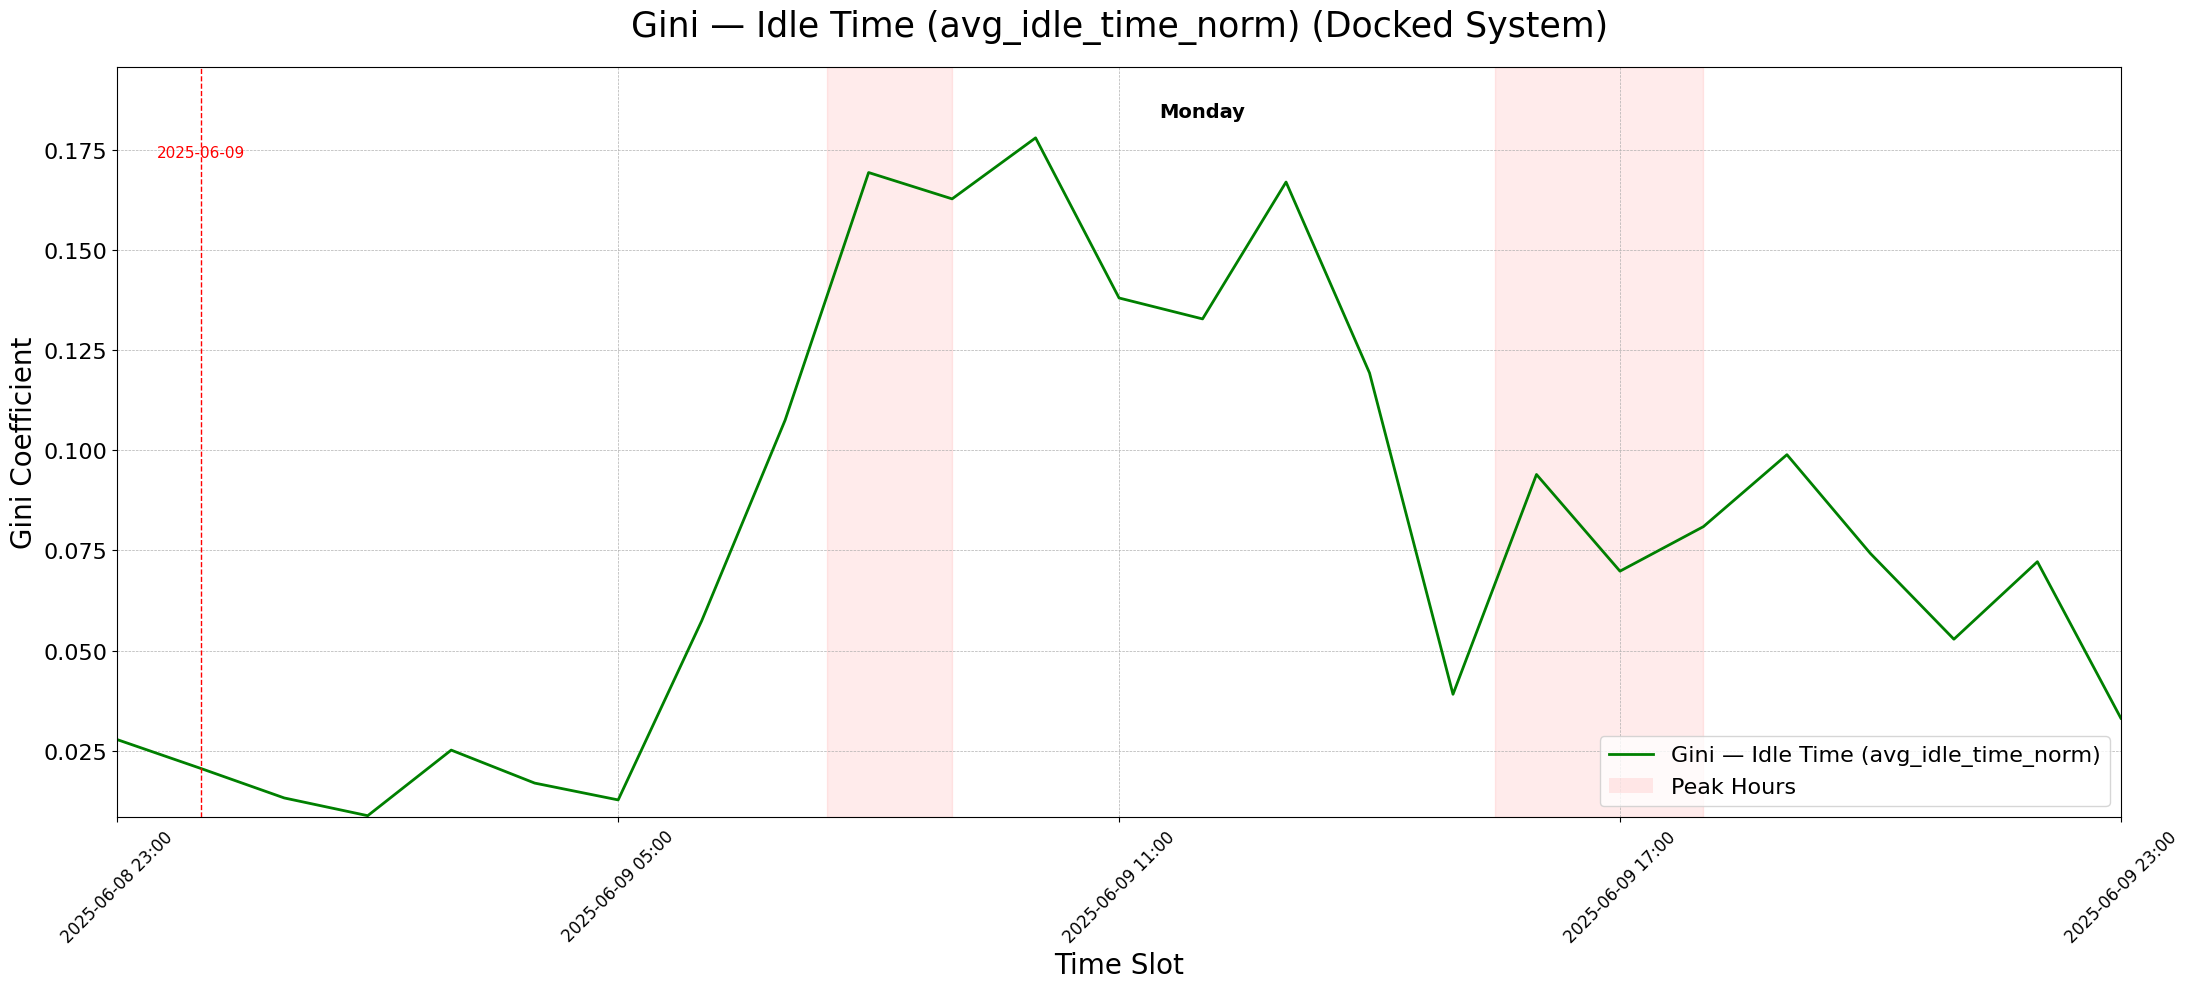

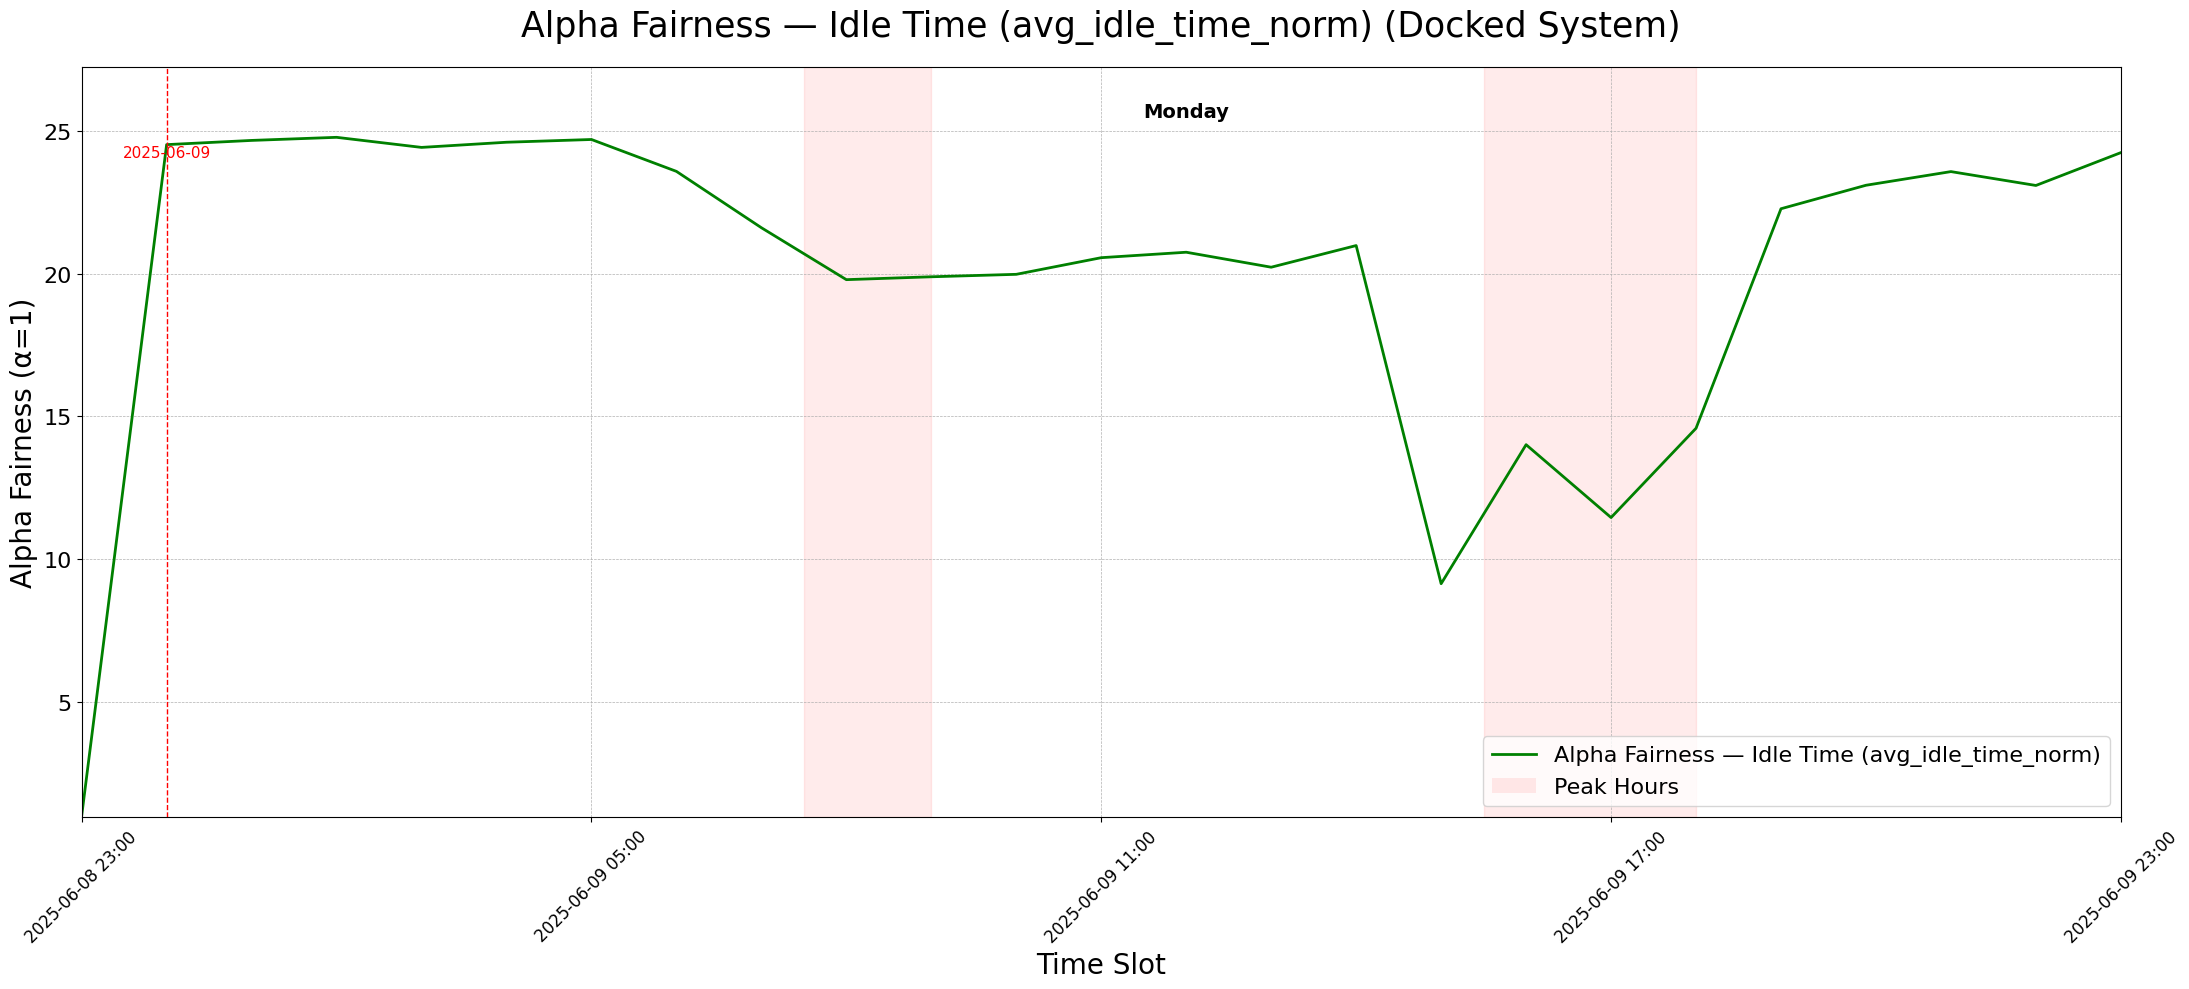

  [Idle Time] Plots saved for: Idle Time (avg_idle_time_norm)
[PITT_DOCKED] All trend plots complete. Outputs in: PITT_OUTPUT\TREND


{'availability': {'plot_paths': {'Availability (num_bikes_available_norm)::MeanSD': 'PITT_OUTPUT\\TREND\\MeanSD_Overall_Availability_num_bikes_available_norm.png',
   'Availability (num_bikes_available_norm)::Gini': 'PITT_OUTPUT\\TREND\\Gini_Overall_Availability_num_bikes_available_norm.png',
   'Availability (num_bikes_available_norm)::Alpha': 'PITT_OUTPUT\\TREND\\AlphaFairness_Overall_Availability_num_bikes_available_norm.png',
   'Availability (num_docks_available_norm)::MeanSD': 'PITT_OUTPUT\\TREND\\MeanSD_Overall_Availability_num_docks_available_norm.png',
   'Availability (num_docks_available_norm)::Gini': 'PITT_OUTPUT\\TREND\\Gini_Overall_Availability_num_docks_available_norm.png',
   'Availability (num_docks_available_norm)::Alpha': 'PITT_OUTPUT\\TREND\\AlphaFairness_Overall_Availability_num_docks_available_norm.png',
   'Availability (num_ebikes_available_norm)::MeanSD': 'PITT_OUTPUT\\TREND\\MeanSD_Overall_Availability_num_ebikes_available_norm.png',
   'Availability (num_ebik

In [12]:
# ============================================================
# Cell 9 — Fairness Trend
# ============================================================

# Set to "single" to use today's outputs, "weekly" for a full week
TREND_MODE = "single"

if TREND_MODE == "single":
    availability_input = f"{PITT_OUT}/availability__norm__tract.csv"
    usage_input        = f"{PITT_OUT}/usage_norm_hourly_tract.csv"
    idle_time_input    = f"{PITT_OUT}/idle_time_norm_tract.csv"
    print("Running trend in single-day mode. Plots will be flat — this is expected.")

elif TREND_MODE == "weekly":
    availability_input = f"{PITT_OUT}/WEEKLY/availability"
    usage_input        = f"{PITT_OUT}/WEEKLY/usage"
    idle_time_input    = f"{PITT_OUT}/WEEKLY/idle_time"
    print("Running trend in weekly mode.")

else:
    raise ValueError("TREND_MODE must be 'single' or 'weekly'.")


# ── OPTION A — All three metrics at once ─────────────────────
trend_visual.plot_all(
    city_key       = "PITT_DOCKED",
    output_dir     = f"{PITT_OUT}/TREND",
    capacity_input = f"{PITT_OUT}/capacity_tract_with_vehicle_and_docks_norm.csv",

    availability_input = availability_input,
    usage_input        = usage_input,
    idle_time_input    = idle_time_input,

    filter_to_capacity_service_area = True,
    invalid_time_slots              = None,
    band_alpha                      = 0.20,
)

# ── OPTION B — One metric at a time ──────────────────────────
# Uncomment whichever metric you want and comment out plot_all above.

# Availability only — produces 3 PNGs:
#   MeanSD_Overall_Availability_total_vehicle_available_norm.png
#   Gini_Overall_Availability_total_vehicle_available_norm.png
#   AlphaFairness_Overall_Availability_total_vehicle_available_norm.png
# trend_visual.plot_availability_trend(
#     city_key           = "PITT_DOCKED",
#     output_dir         = f"{PITT_OUT}/TREND",
#     capacity_input     = f"{PITT_OUT}/capacity_tract_with_vehicle_and_docks_norm.csv",
#     availability_input = availability_input,
#     filter_to_capacity_service_area = True,
#     invalid_time_slots = None,
#     band_alpha         = 0.20,
# )

# Usage only — produces 3 PNGs per column (trips_starting_norm, trips_ending_norm):
#   MeanSD_Overall_Usage_trips_starting_norm.png
#   Gini_Overall_Usage_trips_starting_norm.png
#   AlphaFairness_Overall_Usage_trips_starting_norm.png
# trend_visual.plot_usage_trend(
#     city_key       = "PITT_DOCKED",
#     output_dir     = f"{PITT_OUT}/TREND",
#     capacity_input = f"{PITT_OUT}/capacity_tract_with_vehicle_and_docks_norm.csv",
#     usage_input    = usage_input,
#     filter_to_capacity_service_area = True,
#     invalid_time_slots = None,
#     band_alpha         = 0.20,
# )

# Idle time only — produces 3 PNGs:
#   MeanSD_Overall_Idle_Time_avg_idle_time_norm.png
#   Gini_Overall_Idle_Time_avg_idle_time_norm.png
#   AlphaFairness_Overall_Idle_Time_avg_idle_time_norm.png
# trend_visual.plot_idle_time_trend(
#     city_key        = "PITT_DOCKED",
#     output_dir      = f"{PITT_OUT}/TREND",
#     capacity_input  = f"{PITT_OUT}/capacity_tract_with_vehicle_and_docks_norm.csv",
#     idle_time_input = idle_time_input,
#     filter_to_capacity_service_area = True,
#     invalid_time_slots = None,
#     band_alpha         = 0.20,
# )

## Cell 10 — Paper-Style Fairness Summary Table

Renders the fairness results as a publication-ready grouped table
matching the paper format — bold group headers, three-line borders,
Times New Roman font.

**Option A** renders the styled table inline in Jupyter.
**Option B** exports it as a plain CSV for use outside the notebook.

In [13]:
# ============================================================
# Cell 10 — Paper-Style Fairness Summary Table
# ============================================================

# ── OPTION A — Styled table inline in Jupyter ────────────────
table_visual.make_table(
    csv_path    = f"{PITT_FAIR_DIR}/PITT_DOCKED_fairness_results.csv",
    decimals    = 3,
    font_family = "Times New Roman",
    render      = "styler",
)

# ── OPTION B — Export as plain CSV ───────────────────────────
# df = table_visual.make_table(
#     csv_path = f"{PITT_FAIR_DIR}/PITT_DOCKED_fairness_results.csv",
#     render   = "dataframe",
# )
# df.to_csv(f"{PITT_FAIR_DIR}/PITT_DOCKED_fairness_table_export.csv", index=False)
# print("Table exported.")

Utility Metric,Min,Max,Mean,StDev,Gini Coefficient,"Alpha Fairness (α = 1, Normalized)"
Availability,,,,,,
Bikes available,3.250,53.625,12.443,10.143,0.372,5.812
Docks available,6.042,63.500,16.620,11.577,0.340,5.811
E-bikes available,0.417,28.042,6.469,5.459,0.399,4.962
Total vehicles available,3.875,81.708,18.938,15.300,0.369,5.507
Capacity,,,,,,
Dock capacity,2.000,62.000,16.278,11.776,0.340,8.054
Number of stations,1.000,6.000,1.667,1.121,0.284,8.512
Total capacity,15.000,102.000,29.722,20.383,0.307,8.857
Vehicle capacity,2.000,75.000,19.528,15.758,0.405,7.904
